# Pure-space spectral diagnostic: smooth=0.5, latitude once-differenced data

This notebook is copied from the smooth=0.5 pure-space spectral diagnostic, but the response is transformed to a one-step latitude difference before fitting and spectral analysis.

For each longitude column, the transformed observation is

```text
O3(lat[i+1], lon[j]) - O3(lat[i], lon[j])
```

and it is placed at the latitude midpoint with the same longitude. The original notebook is left unchanged.

The goal is to check whether apparent rough smoothness in the undifferenced data was partly absorbing large-scale latitude nonstationarity. This version keeps `smooth=0.5`, compares `nugget_free` and `nugget0`, and uses the same x8/x4/x2/x1 grid thinning.


In [1]:
import gc
import importlib
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.special import gamma, kv

LOCAL_SRC = '/Users/joonwonlee/Documents/GEMS_TCO-1/src'
AMAREL_SRC = '/home/jl2815/tco'
SRC = AMAREL_SRC if Path(AMAREL_SRC).exists() else LOCAL_SRC
if SRC not in sys.path:
    sys.path.insert(0, SRC)

from GEMS_TCO import configuration as config
from GEMS_TCO import orderings
from GEMS_TCO.data_loader import load_data_dynamic_processed
import GEMS_TCO.kernels_space_trend_050726 as kernels_space_trend_050726
import GEMS_TCO.kernels_space_iso_050826 as kernels_space_iso_050826

importlib.reload(kernels_space_trend_050726)
importlib.reload(kernels_space_iso_050826)

from GEMS_TCO.kernels_space_iso_050826 import (
    HybridSpaceIsoTrendVecchiaFit,
    HybridSpaceIsoNoNuggetTrendVecchiaFit,
)

DEVICE = torch.device('cpu')
DTYPE = torch.float64
ROUND_DECIMALS = 4

pd.set_option('display.max_columns', 140)
pd.set_option('display.width', 200)
print('SRC:', SRC)
print('device:', DEVICE)


SRC: /Users/joonwonlee/Documents/GEMS_TCO-1/src
device: cpu


In [2]:
# Experiment config
YEAR = '2024'
MONTH = 7
DAY_IDX = 2                 # 0-based: 2 -> 2024-07-03
HOUR_IDX_LIST = list(range(8))
LAT_RANGE = [-3, 2]
LON_RANGE = [121, 131]

SMOOTH = 0.5
RESOLUTION_STRIDES = [8, 4, 2, 1]
DATA_TRANSFORM = 'lat_once_difference'
LAT_DIFF_SIGN = 'north_minus_south'
MEAN_DESIGN = 'base'  # after latitude differencing, a linear-lat trend becomes an intercept shift

HYBRID_SPEC = {
    'limit_A': 10,
    'target_chunk_size': 512,
}

VARIANTS = {
    'nugget_free': {
        'class': HybridSpaceIsoTrendVecchiaFit,
        'model': 'HybridSpaceIso_A10_exactloc',
        'kernel': 'hybrid_space_iso_tonly_exactloc',
        'p_labels': ['sigmasq', 'range', 'nugget'],
        'init': {'sigmasq': 13.0, 'range': 0.25, 'nugget': 2.5},
    },
    'nugget0': {
        'class': HybridSpaceIsoNoNuggetTrendVecchiaFit,
        'model': 'HybridSpaceIsoNoNugget_A10_exactloc',
        'kernel': 'hybrid_space_iso_nugget0_tonly_exactloc',
        'p_labels': ['sigmasq', 'range'],
        'init': {'sigmasq': 13.0, 'range': 0.25},
    },
}

LBFGS_LR = 1.0
LBFGS_STEPS_FULL = 8
LBFGS_EVAL = 20
LBFGS_HIST = 10
GRAD_TOL = 1e-5

RUN_FULL = True
RUN_SPECTRUM = True

PURE_SPACE_DIR = Path('/Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space')
OUT_DIR = PURE_SPACE_DIR / 'log'
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PREFIX = 'real_1lat_diff_pure_space_spectral_s05_nugget_compare_hybrid_050826'

print('day:', f'{YEAR}{MONTH:02d}{DAY_IDX + 1:02d}')
print('hours:', HOUR_IDX_LIST)
print('strides:', RESOLUTION_STRIDES)
print('smooth:', SMOOTH)
print('data transform:', DATA_TRANSFORM, LAT_DIFF_SIGN)
print('variants:', list(VARIANTS))


day: 20240703
hours: [0, 1, 2, 3, 4, 5, 6, 7]
strides: [8, 4, 2, 1]
smooth: 0.5
data transform: lat_once_difference north_minus_south
variants: ['nugget_free', 'nugget0']


In [3]:
def phys_to_log(init, p_labels):
    return [np.log(init[p]) for p in p_labels]


def backmap(raw, p_labels, variant):
    est = {p: float(np.exp(raw[i])) for i, p in enumerate(p_labels)}
    if 'nugget' not in est:
        est['nugget'] = 0.0
    return est


def make_full_params(variant):
    spec = VARIANTS[variant]
    return [torch.tensor([v], device=DEVICE, dtype=DTYPE, requires_grad=True) for v in phys_to_log(spec['init'], spec['p_labels'])]


def count_valid(input_map):
    return int(sum(((~torch.isnan(v[:, 2])) & (~torch.isnan(v[:, 0])) & (~torch.isnan(v[:, 1]))).sum().item() for v in input_map.values()))


def space_diag(model):
    groups = getattr(model, 'Batched_Groups', []) or []
    if not groups:
        return {'n_batches': 0, 'n_tails': 0, 'mean_m': 0.0, 'max_m': 0, 'largest_batch_n': 0}
    ns = np.asarray([int(g['target_idx'].shape[0]) for g in groups], dtype=np.int64)
    ms = np.asarray([int(g['max_m']) for g in groups], dtype=np.int64)
    return {
        'n_batches': int(len(groups)),
        'n_tails': int(ns.sum()),
        'mean_m': float(ms.mean()),
        'max_m': int(ms.max()),
        'largest_batch_n': int(ns.max()),
    }


def round_df(df, digits=ROUND_DECIMALS):
    out = df.copy()
    num_cols = out.select_dtypes(include=[np.number]).columns
    out[num_cols] = out[num_cols].round(digits)
    return out


def empty_cache():
    gc.collect()
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()


def resolution_label(stride):
    return f'x{int(stride)}'


In [4]:

loader = load_data_dynamic_processed(config.mac_data_load_path)
df_map, _, _, raw_monthly_mean = loader.load_maxmin_ordered_data_bymonthyear(
    lat_lon_resolution=[1, 1],
    mm_cond_number=10,
    years_=[YEAR],
    months_=[MONTH],
    lat_range=LAT_RANGE,
    lon_range=LON_RANGE,
    is_whittle=True,
)
month_keys = sorted(df_map.keys())
day_keys = month_keys[DAY_IDX * 8:(DAY_IDX + 1) * 8]
if len(day_keys) != 8:
    raise ValueError(f'Day {DAY_IDX} has {len(day_keys)} slices, expected 8')

first_df = df_map[day_keys[0]].reset_index(drop=True)
grid_order = (
    first_df
    .assign(_orig_idx=np.arange(len(first_df)))
    .sort_values(['Longitude', 'Latitude', '_orig_idx'], kind='mergesort')['_orig_idx']
    .to_numpy(dtype=np.int64)
)
base_grid_coords_full = first_df.iloc[grid_order][['Latitude', 'Longitude']].to_numpy(dtype=np.float64)

# Base grid topology from the undifferenced data. The loader still uses this
# order; the response is differenced after loading and then placed on the
# midpoint grid below.
_base_lat_key = np.round(base_grid_coords_full[:, 0], 10)
_base_lon_key = np.round(base_grid_coords_full[:, 1], 10)
base_lat_vals = np.sort(np.unique(_base_lat_key))
base_lon_vals = np.sort(np.unique(_base_lon_key))
base_lat_to_row = {float(v): i for i, v in enumerate(base_lat_vals)}
base_lon_to_col = {float(v): i for i, v in enumerate(base_lon_vals)}
base_local_to_row = np.asarray([base_lat_to_row[float(v)] for v in _base_lat_key], dtype=np.int64)
base_local_to_col = np.asarray([base_lon_to_col[float(v)] for v in _base_lon_key], dtype=np.int64)
BASE_N_LAT, BASE_N_LON = len(base_lat_vals), len(base_lon_vals)
BASE_LAT_STEP = float(np.median(np.diff(base_lat_vals))) if BASE_N_LAT > 1 else 1.0
BASE_LON_STEP = float(np.median(np.diff(base_lon_vals))) if BASE_N_LON > 1 else 1.0
base_grid_index = np.full((BASE_N_LAT, BASE_N_LON), -1, dtype=np.int64)
base_grid_index[base_local_to_row, base_local_to_col] = np.arange(len(base_grid_coords_full), dtype=np.int64)
if (base_grid_index < 0).any():
    raise ValueError('Base grid is not complete; latitude differencing needs adjacent lat cells for each longitude.')

# Latitude once difference: north-minus-south, located at latitude midpoints.
LAT_DIFF_LOWER_IDX = np.asarray([
    base_grid_index[r, c]
    for c in range(BASE_N_LON)
    for r in range(BASE_N_LAT - 1)
], dtype=np.int64)
LAT_DIFF_UPPER_IDX = np.asarray([
    base_grid_index[r + 1, c]
    for c in range(BASE_N_LON)
    for r in range(BASE_N_LAT - 1)
], dtype=np.int64)
lat_vals = np.round(0.5 * (base_lat_vals[:-1] + base_lat_vals[1:]), 10)
lon_vals = np.round(base_lon_vals.copy(), 10)
grid_coords_full = np.asarray([[lat, lon] for lon in lon_vals for lat in lat_vals], dtype=np.float64)

# Differenced-grid topology used by both fitting thins and spectral diagnostics.
_lat_key = np.round(grid_coords_full[:, 0], 10)
_lon_key = np.round(grid_coords_full[:, 1], 10)
lat_to_row = {float(np.round(v, 10)): i for i, v in enumerate(lat_vals)}
lon_to_col = {float(np.round(v, 10)): i for i, v in enumerate(lon_vals)}
local_to_row = np.asarray([lat_to_row[float(v)] for v in _lat_key], dtype=np.int64)
local_to_col = np.asarray([lon_to_col[float(v)] for v in _lon_key], dtype=np.int64)
N_LAT, N_LON = len(lat_vals), len(lon_vals)
LAT_STEP = float(np.median(np.diff(lat_vals))) if N_LAT > 1 else BASE_LAT_STEP
LON_STEP = BASE_LON_STEP
LAT_DIFF_LOWER_T = torch.as_tensor(LAT_DIFF_LOWER_IDX, device=DEVICE, dtype=torch.long)
LAT_DIFF_UPPER_T = torch.as_tensor(LAT_DIFF_UPPER_IDX, device=DEVICE, dtype=torch.long)
LAT_DIFF_COORD_T = torch.as_tensor(grid_coords_full, device=DEVICE, dtype=DTYPE)

ANALYSIS_MONTHLY_MEAN = 0.0
print('raw monthly_mean:', round(raw_monthly_mean, 4), '(not subtracted; differencing removes constants)')
print('day keys:', day_keys[0], '...', day_keys[-1])
print('base full grid:', base_grid_coords_full.shape, 'unique lat/lon:', BASE_N_LAT, BASE_N_LON)
print('lat-differenced grid:', grid_coords_full.shape, 'unique lat/lon:', N_LAT, N_LON)
print('base lat/lon step:', BASE_LAT_STEP, BASE_LON_STEP)
print('diff lat/lon step:', LAT_STEP, LON_STEP)


def apply_lat_once_difference(hour_map):
    differenced = {}
    for k, values in hour_map.items():
        values = values.to(DEVICE)
        lower = values.index_select(0, LAT_DIFF_LOWER_T)
        upper = values.index_select(0, LAT_DIFF_UPPER_T)
        diff = upper.clone()
        diff[:, 0:2] = LAT_DIFF_COORD_T.to(device=values.device, dtype=values.dtype)
        diff[:, 2] = upper[:, 2] - lower[:, 2]
        invalid = torch.isnan(upper[:, 2]) | torch.isnan(lower[:, 2])
        diff[invalid, 2] = torch.nan
        differenced[k] = diff.contiguous()
    return differenced


--- Global Monthly Mean for 2024-7: 257.9726 ---
raw monthly_mean: 257.9726 (not subtracted; differencing removes constants)
day keys: 2024_07_y24m07day03_hm00:53 ... 2024_07_y24m07day03_hm07:48
base full grid: (18126, 2) unique lat/lon: 114 159
lat-differenced grid: (17967, 2) unique lat/lon: 113 159
base lat/lon step: 0.04400000000000004 0.06300000000000239
diff lat/lon step: 0.04400000000000004 0.06300000000000239


In [5]:

def load_hour_map(hour_idx):
    key = day_keys[int(hour_idx)]
    hour_df_map = {key: df_map[key]}
    hour_map, _ = loader.load_working_data(
        hour_df_map,
        monthly_mean=ANALYSIS_MONTHLY_MEAN,
        idx_for_datamap=[0, 1],
        ord_mm=grid_order,
        dtype=DTYPE,
        keep_ori=True,
    )
    hour_map = {k: v.to(DEVICE) for k, v in hour_map.items()}
    return apply_lat_once_difference(hour_map), key


def thin_hour_map(hour_map, stride):
    """Thin on the 2D regular grid, not by 1D every-k flattening.

    A stride of 8 means both latitude and longitude grid spacings are multiplied
    by 8. This makes the effective Nyquist interpretation coherent for spectra.
    """
    stride = int(stride)
    if stride <= 0:
        raise ValueError(f'stride must be positive, got {stride}')
    keep = (local_to_row % stride == 0) & (local_to_col % stride == 0)
    thin_idx = np.flatnonzero(keep).astype(np.int64)
    thin_map = {k: v[thin_idx].contiguous() for k, v in hour_map.items()}
    thin_grid = np.ascontiguousarray(grid_coords_full[thin_idx])
    return thin_map, thin_grid, thin_idx


def make_hybrid_ordering(grid_coords):
    coords = np.ascontiguousarray(grid_coords.astype(np.float64))
    hybrid_order = orderings.maxmin_cpp(coords).astype(np.int64)
    ordered_coords = np.ascontiguousarray(coords[hybrid_order])
    nns_map = orderings.find_nns_l2(ordered_coords, max_nn=HYBRID_SPEC['limit_A'])
    return hybrid_order, ordered_coords, nns_map


def build_model(variant, input_map, nns_map):
    spec = VARIANTS[variant]
    return spec['class'](
        smooth=SMOOTH,
        input_map=input_map,
        nns_map=nns_map,
        limit_A=HYBRID_SPEC['limit_A'],
        target_chunk_size=HYBRID_SPEC['target_chunk_size'],
        mean_design=MEAN_DESIGN,
    )


def make_base_row(variant, hour_idx, time_key, stride, n_grid, n_valid, pre_s, fit_s, loss, fit_iter, est, diag):
    spec = VARIANTS[variant]
    row = {
        'date_str': f'{YEAR}{MONTH:02d}{DAY_IDX + 1:02d}',
        'day_idx': DAY_IDX,
        'hour_idx': int(hour_idx),
        'time_key': str(time_key),
        'resolution_stride': int(stride),
        'resolution_label': resolution_label(stride),
        'variant': variant,
        'smooth': float(SMOOTH),
        'mean_design': MEAN_DESIGN,
        'fit_type': 'full',
        'model': spec['model'],
        'kernel': spec['kernel'],
        'coord_mode': 'latitude once difference north-minus-south on adjacent grid rows, placed at lat midpoints; 2D grid thinning by stride in both lat/lon; covariance on differenced midpoint coordinates',
        'loss': float(loss),
        'fit_iter_raw': int(fit_iter),
        'fit_steps_reported': int(fit_iter) + 1,
        'precompute_s': float(pre_s),
        'fit_s': float(fit_s),
        'total_s': float(pre_s + fit_s),
        'n_grid': int(n_grid),
        'n_valid': int(n_valid),
        'valid_fraction': float(n_valid / n_grid) if n_grid else np.nan,
        'est_sigmasq': float(est['sigmasq']),
        'est_range': float(est['range']),
        'est_nugget': float(est.get('nugget', 0.0)),
        **diag,
        'total_conditioning_nominal': HYBRID_SPEC['limit_A'],
        'limit_A': HYBRID_SPEC['limit_A'],
    }
    return row


In [6]:
def fit_full_variant(variant, hour_idx, stride):
    hour_map, time_key = load_hour_map(hour_idx)
    thin_map_regular, thin_grid_regular, _ = thin_hour_map(hour_map, stride)
    hybrid_order, thin_grid, nns_map = make_hybrid_ordering(thin_grid_regular)
    thin_map = {k: v[hybrid_order].contiguous() for k, v in thin_map_regular.items()}
    n_grid = int(thin_grid.shape[0])
    n_valid = count_valid(thin_map)
    print('\n' + '=' * 100)
    print(f'{variant} | smooth={SMOOTH} | hour={hour_idx + 1} | {time_key} | {resolution_label(stride)} | n_grid={n_grid:,} | n_valid={n_valid:,}')

    model = build_model(variant, thin_map, nns_map)
    t_pre = time.time()
    model.precompute_conditioning_sets()
    pre_s = time.time() - t_pre
    diag = space_diag(model)

    params = make_full_params(variant)
    opt = model.set_optimizer(params, lr=LBFGS_LR, max_iter=LBFGS_EVAL, max_eval=LBFGS_EVAL, history_size=LBFGS_HIST)
    t_fit = time.time()
    out, fit_iter = model.fit_vecc_lbfgs(params, opt, max_steps=LBFGS_STEPS_FULL, grad_tol=GRAD_TOL)
    fit_s = time.time() - t_fit
    p_labels = VARIANTS[variant]['p_labels']
    est = backmap(out[:len(p_labels)], p_labels, variant)
    row = make_base_row(variant, hour_idx, time_key, stride, n_grid, n_valid, pre_s, fit_s, out[-1], fit_iter, est, diag)
    print('RESULT:', {k: round(v, 4) if isinstance(v, float) else v for k, v in row.items() if k in ['variant','resolution_label','loss','est_sigmasq','est_range','est_nugget','total_s']})

    del model, params, opt, hour_map, thin_map
    empty_cache()
    return row


In [7]:
fit_rows = []
if RUN_FULL:
    for variant in VARIANTS:
        for hour_idx in HOUR_IDX_LIST:
            for stride in RESOLUTION_STRIDES:
                fit_rows.append(fit_full_variant(variant, hour_idx, stride))
                tmp = round_df(pd.DataFrame(fit_rows))
                tmp.to_csv(OUT_DIR / f'{OUT_PREFIX}_full.csv', index=False, float_format=f'%.{ROUND_DECIMALS}f')

fit_df = pd.DataFrame(fit_rows)
full_path = OUT_DIR / f'{OUT_PREFIX}_full.csv'
round_df(fit_df).to_csv(full_path, index=False, float_format=f'%.{ROUND_DECIMALS}f')
print('Saved full fits:', full_path)
display(round_df(fit_df))

param_rows = []
for _, row in fit_df.iterrows():
    for p in ['sigmasq', 'range', 'nugget']:
        param_rows.append({
            'date_str': row['date_str'],
            'hour_idx': int(row['hour_idx']),
            'time_key': row['time_key'],
            'resolution_stride': int(row['resolution_stride']),
            'resolution_label': row['resolution_label'],
            'variant': row['variant'],
            'smooth': row['smooth'],
            'parameter': p,
            'estimate': row[f'est_{p}'],
            'loss': row['loss'],
            'n_grid': row['n_grid'],
            'n_valid': row['n_valid'],
        })
param_df = pd.DataFrame(param_rows)
param_path = OUT_DIR / f'{OUT_PREFIX}_param_table.csv'
round_df(param_df).to_csv(param_path, index=False, float_format=f'%.{ROUND_DECIMALS}f')
print('Saved param table:', param_path)



nugget_free | smooth=0.5 | hour=1 | 2024_07_y24m07day03_hm00:53 | x8 | n_grid=300 | n_valid=300
Pre-computing HybridSpaceVecchia [A=10]... Done in 0.0s. tails=300, m mean/med/max=9.8/10/10
--- Starting Pure-Space Vecchia L-BFGS ---
--- Step 1/8 / Loss: 1.638210 / Max Grad: 1.89e-05 ---
--- Step 2/8 / Loss: 1.547899 / Max Grad: 3.85e-06 ---
Converged: max_grad 3.85e-06 < 1.00e-05
Final Pure-Space Params: {'sigmasq': 5.15639764147275, 'range': 0.026606345248892816, 'nugget': 2.975437490750683}
RESULT: {'resolution_label': 'x8', 'variant': 'nugget_free', 'loss': 1.5479, 'total_s': 0.0675, 'est_sigmasq': 5.1564, 'est_range': 0.0266, 'est_nugget': 2.9754}

nugget_free | smooth=0.5 | hour=1 | 2024_07_y24m07day03_hm00:53 | x4 | n_grid=1,160 | n_valid=1,160
Pre-computing HybridSpaceVecchia [A=10]... Done in 0.0s. tails=1160, m mean/med/max=10.0/10/10
--- Starting Pure-Space Vecchia L-BFGS ---
--- Step 1/8 / Loss: 1.602170 / Max Grad: 1.28e-04 ---
--- Step 2/8 / Loss: 1.511672 / Max Grad: 2.02

,date_str,day_idx,hour_idx,time_key,resolution_stride,resolution_label,variant,smooth,mean_design,fit_type,model,kernel,coord_mode,loss,fit_iter_raw,fit_steps_reported,precompute_s,fit_s,total_s,n_grid,n_valid,valid_fraction,est_sigmasq,est_range,est_nugget,n_batches,n_tails,mean_m,max_m,largest_batch_n,total_conditioning_nominal,limit_A
0,20240703,2,0,2024_07_y24m07day03_hm00:53,8,x8,nugget_free,0.5,base,full,HybridSpaceIso_A10_exactloc,hybrid_space_iso_tonly_exactloc,latitude once difference north-minus-south on ...,1.5479,1,2,0.0020,0.0655,0.0675,300,300,1.0000,5.1564,0.0266,2.9754,1,300,10.0,10,300,10,10
1,20240703,2,0,2024_07_y24m07day03_hm00:53,4,x4,nugget_free,0.5,base,full,HybridSpaceIso_A10_exactloc,hybrid_space_iso_tonly_exactloc,latitude once difference north-minus-south on ...,1.5117,1,2,0.0040,0.4329,0.4369,1160,1160,1.0000,0.5731,0.0129,6.9905,1,1160,10.0,10,1160,10,10
2,20240703,2,0,2024_07_y24m07day03_hm00:53,2,x2,nugget_free,0.5,base,full,HybridSpaceIso_A10_exactloc,hybrid_space_iso_tonly_exactloc,latitude once difference north-minus-south on ...,1.7158,1,2,0.0366,0.8343,0.8709,4560,4529,0.9932,3.2846,0.0054,8.0936,1,4529,10.0,10,4529,10,10
3,20240703,2,0,2024_07_y24m07day03_hm00:53,1,x1,nugget_free,0.5,base,full,HybridSpaceIso_A10_exactloc,hybrid_space_iso_tonly_exactloc,latitude once difference north-minus-south on ...,1.6313,1,2,0.0898,2.3443,2.4341,17967,17905,0.9965,0.0000,0.0139,9.6072,1,17905,10.0,10,17905,10,10
4,20240703,2,1,2024_07_y24m07day03_hm01:53,8,x8,nugget_free,0.5,base,full,HybridSpaceIso_A10_exactloc,hybrid_space_iso_tonly_exactloc,latitude once difference north-minus-south on ...,1.5017,1,2,0.0011,0.0419,0.0430,300,288,0.9600,4.1615,0.0233,3.2534,1,288,10.0,10,288,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,20240703,2,6,2024_07_y24m07day03_hm06:48,1,x1,nugget0,0.5,base,full,HybridSpaceIsoNoNugget_A10_exactloc,hybrid_space_iso_nugget0_tonly_exactloc,latitude once difference north-minus-south on ...,1.5631,1,2,0.1428,1.8097,1.9525,17967,17942,0.9986,8.3822,0.0033,0.0000,1,17942,10.0,10,17942,10,10
60,20240703,2,7,2024_07_y24m07day03_hm07:48,8,x8,nugget0,0.5,base,full,HybridSpaceIsoNoNugget_A10_exactloc,hybrid_space_iso_nugget0_tonly_exactloc,latitude once difference north-minus-south on ...,1.6427,0,1,0.0013,0.0343,0.0355,300,297,0.9900,8.7138,0.0286,0.0000,1,297,10.0,10,297,10,10
61,20240703,2,7,2024_07_y24m07day03_hm07:48,4,x4,nugget0,0.5,base,full,HybridSpaceIsoNoNugget_A10_exactloc,hybrid_space_iso_nugget0_tonly_exactloc,latitude once difference north-minus-south on ...,1.6146,0,1,0.0079,0.3005,0.3084,1160,1154,0.9948,7.6493,0.0382,0.0000,1,1154,10.0,10,1154,10,10
62,20240703,2,7,2024_07_y24m07day03_hm07:48,2,x2,nugget0,0.5,base,full,HybridSpaceIsoNoNugget_A10_exactloc,hybrid_space_iso_nugget0_tonly_exactloc,latitude once difference north-minus-south on ...,1.5196,1,2,0.0351,0.6870,0.7222,4560,4548,0.9974,7.6846,0.0069,0.0000,1,4548,10.0,10,4548,10,10


Saved param table: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_1lat_diff_pure_space_spectral_s05_nugget_compare_hybrid_050826_param_table.csv


In [8]:
# Full-fit results table.
plot_df = fit_df.copy()
plot_df['resolution_label'] = pd.Categorical(
    plot_df['resolution_label'], categories=[f'x{s}' for s in RESOLUTION_STRIDES], ordered=True
)
plot_df = plot_df.sort_values(['variant', 'hour_idx', 'resolution_label'])

display(round_df(plot_df[['variant','hour_idx','resolution_stride','resolution_label','loss','est_sigmasq','est_range','est_nugget','n_grid','n_valid','total_s']]))


,variant,hour_idx,resolution_stride,resolution_label,loss,est_sigmasq,est_range,est_nugget,n_grid,n_valid,total_s
32,nugget0,0,8,x8,1.6098,8.1318,0.0276,0.0000,300,300,0.0356
33,nugget0,0,4,x4,1.5117,7.5635,0.0113,0.0000,1160,1160,0.3696
34,nugget0,0,2,x2,2.3398,11.3779,0.0073,0.0000,4560,4529,0.5296
35,nugget0,0,1,x1,1.6313,9.6074,0.0025,0.0000,17967,17905,2.2261
36,nugget0,1,8,x8,1.5821,7.4149,0.0265,0.0000,300,288,0.0301
...,...,...,...,...,...,...,...,...,...,...,...
27,nugget_free,6,1,x1,1.5631,0.0000,0.0503,8.3822,17967,17942,2.3588
28,nugget_free,7,8,x8,1.6637,5.3899,0.0272,3.3239,300,297,0.0380
29,nugget_free,7,4,x4,1.5169,0.1358,0.5425,7.5131,1160,1154,0.4765
30,nugget_free,7,2,x2,1.5196,0.3230,0.0077,7.3617,4560,4548,0.7186


Pre-computing HybridSpaceVecchia [A=10]... Done in 0.0s. tails=300, m mean/med/max=9.8/10/10

------------------------------------------------------------------------------------------
profile=sigma_only | nugget_free | hour=1 | x8 | anchor={'sigmasq': 5.15639764147275, 'range': 0.026606345248892816, 'nugget': 2.975437490750683}
    sigma_only step 1/8: loss=1.547899, grad=3.85e-06

------------------------------------------------------------------------------------------
profile=range_only | nugget_free | hour=1 | x8 | anchor={'sigmasq': 5.15639764147275, 'range': 0.026606345248892816, 'nugget': 2.975437490750683}
    range_only step 1/8: loss=1.547899, grad=1.03e-07
Pre-computing HybridSpaceVecchia [A=10]... Done in 0.0s. tails=1160, m mean/med/max=10.0/10/10

------------------------------------------------------------------------------------------
profile=sigma_only | nugget_free | hour=1 | x4 | anchor={'sigmasq': 0.5730593750537708, 'range': 0.012929361812422146, 'nugget': 6.99054

,variant,profile_type,hour_idx,resolution_stride,resolution_label,loss,est_sigmasq,est_range,est_nugget,fixed_sigmasq,fixed_range,fixed_nugget,n_grid,n_valid,total_s
0,nugget_free,sigma_only,0,8,x8,1.5479,5.1564,0.0266,2.9754,NaN,0.0266,2.9754,300,300,0.0038
1,nugget_free,range_only,0,8,x8,1.5479,5.1564,0.0266,2.9754,5.1564,NaN,2.9754,300,300,0.0040
2,nugget_free,sigma_only,0,4,x4,1.5117,0.5731,0.0129,6.9905,NaN,0.0129,6.9905,1160,1160,0.0421
3,nugget_free,range_only,0,4,x4,1.5117,0.5731,0.0129,6.9905,0.5731,NaN,6.9905,1160,1160,0.0444
4,nugget_free,sigma_only,0,2,x2,1.7158,3.2846,0.0054,8.0936,NaN,0.0054,8.0936,4560,4529,0.2394
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,nugget0,range_only,7,4,x4,1.5173,7.6493,0.0382,0.0000,7.6493,NaN,0.0000,1160,1154,0.0549
124,nugget0,sigma_only,7,2,x2,1.5196,7.6846,0.0069,0.0000,NaN,0.0069,0.0000,4560,4548,0.2725
125,nugget0,range_only,7,2,x2,1.5196,7.6846,0.0069,0.0000,7.6846,NaN,0.0000,4560,4548,0.1113
126,nugget0,sigma_only,7,1,x1,1.5811,8.6910,0.0027,0.0000,NaN,0.0027,0.0000,17967,17943,0.2965


Saved combined parameter plot: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_1lat_diff_pure_space_spectral_s05_nugget_compare_hybrid_050826_parameter_trajectories.png


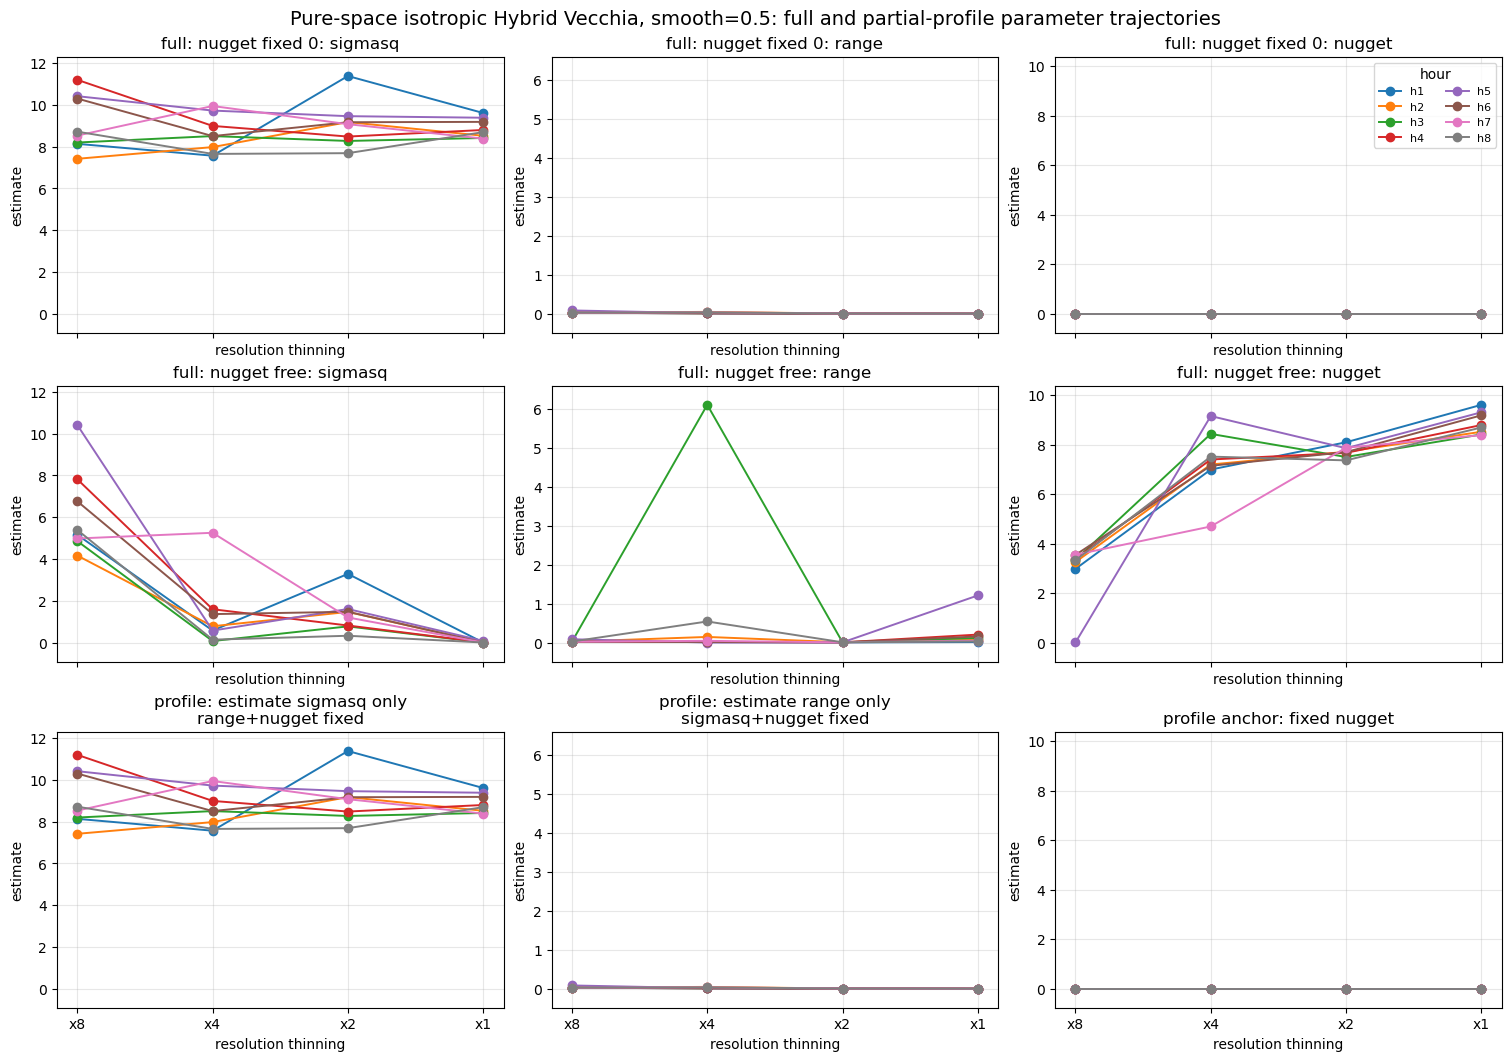

In [9]:
# %%
# Partial-profile fits anchored at the full-fit estimates.
# sigma_only: estimate sigmasq only; keep range and nugget fixed at the full-fit estimates.
# range_only: estimate range only; keep sigmasq and nugget fixed at the full-fit estimates.
RUN_PROFILE_FITS = True
PROFILE_TYPES = ['sigma_only', 'range_only']
PROFILE_LBFGS_STEPS = 8
PROFILE_GRAD_TOL = 1e-5
PROFILE_EPS = 1e-10


def safe_log_value(x, eps=PROFILE_EPS):
    return float(np.log(max(float(x), eps)))


def log_tensor_value(x, like, eps=PROFILE_EPS):
    return torch.as_tensor(np.log(max(float(x), eps)), device=like.device, dtype=like.dtype)


def profile_param_tensor(variant, profile_type, theta, anchor):
    if variant == 'nugget_free':
        vals = {
            'sigmasq': log_tensor_value(anchor['sigmasq'], theta),
            'range': log_tensor_value(anchor['range'], theta),
            'nugget': log_tensor_value(anchor['nugget'], theta),
        }
        vals['sigmasq' if profile_type == 'sigma_only' else 'range'] = theta.reshape(())
        return torch.stack([vals['sigmasq'], vals['range'], vals['nugget']])
    if variant == 'nugget0':
        vals = {
            'sigmasq': log_tensor_value(anchor['sigmasq'], theta),
            'range': log_tensor_value(anchor['range'], theta),
        }
        vals['sigmasq' if profile_type == 'sigma_only' else 'range'] = theta.reshape(())
        return torch.stack([vals['sigmasq'], vals['range']])
    raise ValueError(f'Unknown variant: {variant}')


def profile_estimate_from_theta(profile_type, theta, anchor):
    est = dict(anchor)
    est['sigmasq' if profile_type == 'sigma_only' else 'range'] = float(torch.exp(theta.detach()).cpu().item())
    return est


def optimize_profile(model, variant, profile_type, anchor):
    free_name = 'sigmasq' if profile_type == 'sigma_only' else 'range'
    theta = torch.tensor([safe_log_value(anchor[free_name])], device=DEVICE, dtype=DTYPE, requires_grad=True)
    optimizer = torch.optim.LBFGS(
        [theta],
        lr=LBFGS_LR,
        max_iter=LBFGS_EVAL,
        max_eval=LBFGS_EVAL,
        history_size=LBFGS_HIST,
        line_search_fn='strong_wolfe',
    )

    last_loss = None
    last_iter = 0
    for i in range(PROFILE_LBFGS_STEPS):
        last_iter = i

        def closure():
            optimizer.zero_grad()
            params = profile_param_tensor(variant, profile_type, theta, anchor)
            loss = model.vecchia_batched_likelihood(params)
            loss.backward()
            return loss

        last_loss = optimizer.step(closure)
        with torch.no_grad():
            max_grad = abs(float(theta.grad.detach().item())) if theta.grad is not None else 0.0
            print(f'    {profile_type} step {i + 1}/{PROFILE_LBFGS_STEPS}: loss={float(last_loss.detach().item()):.6f}, grad={max_grad:.2e}')
            if max_grad < PROFILE_GRAD_TOL:
                break

    est = profile_estimate_from_theta(profile_type, theta, anchor)
    loss = float(last_loss.detach().cpu().item()) if isinstance(last_loss, torch.Tensor) else np.nan
    return est, loss, last_iter


def fit_partial_profiles_for_row(row):
    variant = str(row['variant'])
    hour_idx = int(row['hour_idx'])
    stride = int(row['resolution_stride'])
    anchor = {
        'sigmasq': float(row['est_sigmasq']),
        'range': float(row['est_range']),
        'nugget': float(row.get('est_nugget', 0.0)),
    }

    hour_map, time_key = load_hour_map(hour_idx)
    thin_map_regular, thin_grid_regular, _ = thin_hour_map(hour_map, stride)
    hybrid_order, thin_grid, nns_map = make_hybrid_ordering(thin_grid_regular)
    thin_map = {k: v[hybrid_order].contiguous() for k, v in thin_map_regular.items()}
    model = build_model(variant, thin_map, nns_map)
    t_pre = time.time()
    model.precompute_conditioning_sets()
    pre_s = time.time() - t_pre
    diag = space_diag(model)

    out_rows = []
    for profile_type in PROFILE_TYPES:
        print('\n' + '-' * 90)
        print(f"profile={profile_type} | {variant} | hour={hour_idx + 1} | {resolution_label(stride)} | anchor={anchor}")
        t_fit = time.time()
        est, loss, fit_iter = optimize_profile(model, variant, profile_type, anchor)
        fit_s = time.time() - t_fit
        profile_row = dict(row)
        profile_row.update({
            'fit_type': profile_type,
            'profile_type': profile_type,
            'fixed_sigmasq': anchor['sigmasq'] if profile_type == 'range_only' else np.nan,
            'fixed_range': anchor['range'] if profile_type == 'sigma_only' else np.nan,
            'fixed_nugget': anchor['nugget'],
            'loss': float(loss),
            'fit_iter_raw': int(fit_iter),
            'fit_steps_reported': int(fit_iter) + 1,
            'precompute_s': float(pre_s),
            'fit_s': float(fit_s),
            'total_s': float(pre_s + fit_s),
            'est_sigmasq': float(est['sigmasq']),
            'est_range': float(est['range']),
            'est_nugget': float(est.get('nugget', 0.0)),
            **diag,
        })
        out_rows.append(profile_row)

    del model, hour_map, thin_map_regular, thin_map
    empty_cache()
    return out_rows


profile_path = OUT_DIR / f'{OUT_PREFIX}_partial_profile.csv'
if RUN_PROFILE_FITS:
    if 'fit_df' not in globals() or fit_df.empty:
        fit_df = pd.read_csv(OUT_DIR / f'{OUT_PREFIX}_full.csv')

    profile_rows = []
    for _, fit_row in fit_df.iterrows():
        profile_rows.extend(fit_partial_profiles_for_row(fit_row))
        tmp = round_df(pd.DataFrame(profile_rows))
        tmp.to_csv(profile_path, index=False, float_format=f'%.{ROUND_DECIMALS}f')

    profile_df = pd.DataFrame(profile_rows)
    round_df(profile_df).to_csv(profile_path, index=False, float_format=f'%.{ROUND_DECIMALS}f')
else:
    profile_df = pd.read_csv(profile_path) if profile_path.exists() else pd.DataFrame()

print('Saved partial-profile fits:', profile_path)
display(round_df(profile_df[['variant','profile_type','hour_idx','resolution_stride','resolution_label','loss','est_sigmasq','est_range','est_nugget','fixed_sigmasq','fixed_range','fixed_nugget','n_grid','n_valid','total_s']]))

# %%
# Combined parameter trajectories:
# row 1: nugget0 full fit
# row 2: nugget_free full fit
# row 3: nugget0 partial profiles anchored at the full-fit estimates
if 'fit_df' not in globals() or fit_df.empty:
    fit_df = pd.read_csv(OUT_DIR / f'{OUT_PREFIX}_full.csv')
if 'profile_df' not in globals() or profile_df.empty:
    profile_df = pd.read_csv(OUT_DIR / f'{OUT_PREFIX}_partial_profile.csv')

full_plot_df = fit_df.copy()
full_plot_df['resolution_label'] = pd.Categorical(
    full_plot_df['resolution_label'], categories=[f'x{s}' for s in RESOLUTION_STRIDES], ordered=True
)
full_plot_df = full_plot_df.sort_values(['variant', 'hour_idx', 'resolution_label'])

prof_plot_df = profile_df.copy()
prof_plot_df['resolution_label'] = pd.Categorical(
    prof_plot_df['resolution_label'], categories=[f'x{s}' for s in RESOLUTION_STRIDES], ordered=True
)
prof_plot_df = prof_plot_df.sort_values(['variant', 'profile_type', 'hour_idx', 'resolution_label'])
prof_anchor_variant = 'nugget0'

combined_param_values = {
    'sigmasq': [full_plot_df['est_sigmasq'], prof_plot_df.loc[prof_plot_df['profile_type'] == 'sigma_only', 'est_sigmasq']],
    'range': [full_plot_df['est_range'], prof_plot_df.loc[prof_plot_df['profile_type'] == 'range_only', 'est_range']],
    'nugget': [full_plot_df['est_nugget'], prof_plot_df['fixed_nugget']],
}
combined_param_ylims = {}
for p, series_list in combined_param_values.items():
    vals = pd.concat([pd.to_numeric(s, errors='coerce') for s in series_list], ignore_index=True)
    vals = vals.replace([np.inf, -np.inf], np.nan).dropna()
    if vals.empty:
        combined_param_ylims[p] = (0.0, 1.0)
        continue
    lo, hi = float(vals.min()), float(vals.max())
    pad = max(abs(hi) * 0.05, 0.05) if np.isclose(lo, hi) else 0.08 * (hi - lo)
    if p == 'nugget':
        lo = min(0.0, lo)
    combined_param_ylims[p] = (lo - pad, hi + pad)

fig, axes = plt.subplots(3, 3, figsize=(15, 10.5), constrained_layout=True, sharex=True)
full_rows = [('nugget0', 'full: nugget fixed 0'), ('nugget_free', 'full: nugget free')]
params_to_plot = ['sigmasq', 'range', 'nugget']
for r, (variant, row_label) in enumerate(full_rows):
    sub_v = full_plot_df[full_plot_df['variant'] == variant]
    for c, p in enumerate(params_to_plot):
        ax = axes[r, c]
        for hour_idx, sub in sub_v.groupby('hour_idx'):
            ax.plot(sub['resolution_label'].astype(str), sub[f'est_{p}'], marker='o', linewidth=1.4, label=f'h{int(hour_idx)+1}')
        ax.set_title(f'{row_label}: {p}')
        ax.set_xlabel('resolution thinning')
        ax.set_ylabel('estimate')
        ax.set_ylim(*combined_param_ylims[p])
        ax.grid(True, alpha=0.3)

sigma_prof = prof_plot_df[(prof_plot_df['variant'] == prof_anchor_variant) & (prof_plot_df['profile_type'] == 'sigma_only')]
range_prof = prof_plot_df[(prof_plot_df['variant'] == prof_anchor_variant) & (prof_plot_df['profile_type'] == 'range_only')]

ax = axes[2, 0]
for hour_idx, sub in sigma_prof.groupby('hour_idx'):
    ax.plot(sub['resolution_label'].astype(str), sub['est_sigmasq'], marker='o', linewidth=1.4, label=f'h{int(hour_idx)+1}')
ax.set_title('profile: estimate sigmasq only\nrange+nugget fixed')
ax.set_xlabel('resolution thinning')
ax.set_ylabel('estimate')
ax.set_ylim(*combined_param_ylims['sigmasq'])
ax.grid(True, alpha=0.3)

ax = axes[2, 1]
for hour_idx, sub in range_prof.groupby('hour_idx'):
    ax.plot(sub['resolution_label'].astype(str), sub['est_range'], marker='o', linewidth=1.4, label=f'h{int(hour_idx)+1}')
ax.set_title('profile: estimate range only\nsigmasq+nugget fixed')
ax.set_xlabel('resolution thinning')
ax.set_ylabel('estimate')
ax.set_ylim(*combined_param_ylims['range'])
ax.grid(True, alpha=0.3)

ax = axes[2, 2]
for hour_idx, sub in sigma_prof.groupby('hour_idx'):
    ax.plot(sub['resolution_label'].astype(str), sub['fixed_nugget'], marker='o', linewidth=1.4, label=f'h{int(hour_idx)+1}')
ax.set_title('profile anchor: fixed nugget')
ax.set_xlabel('resolution thinning')
ax.set_ylabel('estimate')
ax.set_ylim(*combined_param_ylims['nugget'])
ax.grid(True, alpha=0.3)

axes[0, -1].legend(ncol=2, fontsize=8, title='hour')
fig.suptitle(f'Pure-space isotropic Hybrid Vecchia, smooth={SMOOTH}: full and partial-profile parameter trajectories', fontsize=14)
param_plot_path = OUT_DIR / f'{OUT_PREFIX}_parameter_trajectories.png'
fig.savefig(param_plot_path, dpi=180, bbox_inches='tight')
print('Saved combined parameter plot:', param_plot_path)
plt.show()


## Spectral diagnostic

The empirical spectrum uses the same thinned points as each fit. Residuals are computed after an OLS `intercept + lat` detrend, placed back onto the thinned 2D grid, tapered, zero-filled, FFTed, and radially averaged. The main theory curve is now a DW-style finite-sample expected periodogram: the fitted Matérn covariance plus nugget is passed through the same mask/taper/FFT normalization before radial averaging, without median scaling.

The primary radial figure compares data to this expected periodogram. The median-matched Matérn curve is saved separately with `shape_diagnostic` in the filename for shape-only comparison. Raw continuous `f(omega)` is used only internally to form that scaled shape curve; raw `f(omega)` plots and CSV columns are not part of the output.


In [10]:

SPECTRAL_SMOOTH = SMOOTH
RADIAL_N_BINS = 70
RADIAL_QMAX = 0.985
APPLY_HANN = True
EPS = 1e-12

print('spectral full grid:', (N_LAT, N_LON), 'lat/lon step:', LAT_STEP, LON_STEP)


def trend_design(lat, lon, lat_center=None, lon_center=None):
    lat_center = np.nanmean(lat) if lat_center is None else float(lat_center)
    lon_center = np.nanmean(lon) if lon_center is None else float(lon_center)
    lat_c = lat - lat_center
    lon_c = lon - lon_center
    if MEAN_DESIGN in ('base', 'lat'):
        return np.column_stack([np.ones(len(lat)), lat_c])
    # Keep the residual trend matched to the fitted mean design.
    return np.column_stack([np.ones(len(lat)), lat_c, lon_c])


def detrended_residual_grid(hour_idx, stride):
    hour_map, time_key = load_hour_map(hour_idx)
    thin_map, thin_grid, thin_idx = thin_hour_map(hour_map, stride)
    arr = next(iter(thin_map.values())).detach().cpu().numpy()
    y = arr[:, 2].astype(float)
    lat = arr[:, 0].astype(float)
    lon = arr[:, 1].astype(float)
    valid = np.isfinite(y) & np.isfinite(lat) & np.isfinite(lon)
    if valid.sum() < 4:
        raise ValueError(f'Not enough valid points for hour={hour_idx}, stride={stride}')

    lat_center = np.nanmean(lat[valid])
    lon_center = np.nanmean(lon[valid])
    X = trend_design(lat[valid], lon[valid], lat_center=lat_center, lon_center=lon_center)
    beta, *_ = np.linalg.lstsq(X, y[valid], rcond=None)
    X_all = trend_design(lat, lon, lat_center=lat_center, lon_center=lon_center)
    resid = y - X_all @ beta

    rows_full = local_to_row[thin_idx]
    cols_full = local_to_col[thin_idx]
    row_keep = np.sort(np.unique(rows_full))
    col_keep = np.sort(np.unique(cols_full))
    row_pos = {int(r): i for i, r in enumerate(row_keep)}
    col_pos = {int(c): i for i, c in enumerate(col_keep)}

    grid = np.full((len(row_keep), len(col_keep)), np.nan, dtype=float)
    mask = np.zeros_like(grid, dtype=float)
    rr = np.asarray([row_pos[int(r)] for r in rows_full[valid]], dtype=np.int64)
    cc = np.asarray([col_pos[int(c)] for c in cols_full[valid]], dtype=np.int64)
    grid[rr, cc] = resid[valid]
    mask[rr, cc] = 1.0

    lat_axis = lat_vals[row_keep].astype(float)
    lon_axis = lon_vals[col_keep].astype(float)
    return grid, mask, time_key, int(valid.sum()), lat_axis, lon_axis


def masked_periodogram(grid, mask):
    obs = mask > 0
    if not np.any(obs):
        raise ValueError('No observed cells in spectral grid.')
    z = np.zeros_like(grid, dtype=float)
    z[obs] = grid[obs]
    win = np.outer(np.hanning(z.shape[0]), np.hanning(z.shape[1])) if APPLY_HANN else np.ones_like(z)
    zw = z * win
    norm = np.sum((mask * win) ** 2)
    norm = norm if norm > EPS else 1.0
    return np.abs(np.fft.fftshift(np.fft.fft2(zw))) ** 2 / norm


def matern_covariance_lag(sigmasq, range_, nugget, smooth, lag_lat, lag_lon):
    lag_lat = np.asarray(lag_lat, dtype=float)
    lag_lon = np.asarray(lag_lon, dtype=float)
    r = np.sqrt(lag_lat ** 2 + lag_lon ** 2) / max(float(range_), EPS)
    nu = float(smooth)
    if np.isclose(nu, 0.5):
        corr = np.exp(-r)
    elif np.isclose(nu, 1.5):
        corr = (1.0 + r) * np.exp(-r)
    else:
        corr = np.ones_like(r, dtype=float)
        positive = r > EPS
        if np.any(positive):
            scaled = np.sqrt(2.0 * nu) * r[positive]
            corr[positive] = (2.0 ** (1.0 - nu) / gamma(nu)) * (scaled ** nu) * kv(nu, scaled)
        corr = np.nan_to_num(corr, nan=0.0, posinf=0.0, neginf=0.0)
    cov = float(sigmasq) * corr
    zero_lag = (np.abs(lag_lat) < EPS) & (np.abs(lag_lon) < EPS)
    return cov + max(float(nugget), 0.0) * zero_lag


def taper_mask_autocorrelation(mask):
    mask = np.asarray(mask, dtype=float)
    win = np.outer(np.hanning(mask.shape[0]), np.hanning(mask.shape[1])) if APPLY_HANN else np.ones_like(mask)
    g = mask * win
    H = float(np.sum(g ** 2))
    if H <= EPS:
        raise ValueError('Taper/mask normalization is zero.')
    n1, n2 = g.shape
    G = np.fft.fft2(g, s=(2 * n1 - 1, 2 * n2 - 1))
    ac = np.fft.fftshift(np.fft.ifft2(G * np.conj(G)).real) / H
    return ac, H


def _autocorr_for_lags(ac, lag1, lag2, n1, n2):
    out = np.zeros_like(lag1, dtype=float)
    valid = (np.abs(lag1) <= n1 - 1) & (np.abs(lag2) <= n2 - 1)
    if np.any(valid):
        out[valid] = ac[(n1 - 1 + lag1[valid]).astype(int), (n2 - 1 + lag2[valid]).astype(int)]
    return out


def covariance_lag_kernel(sigmasq, range_, nugget, smooth, n1, n2, dlat, dlon):
    lag1_vals = np.arange(-(n1 - 1), n1, dtype=int)
    lag2_vals = np.arange(-(n2 - 1), n2, dtype=int)
    lag1, lag2 = np.meshgrid(lag1_vals, lag2_vals, indexing='ij')
    return matern_covariance_lag(sigmasq, range_, nugget, smooth, lag1 * dlat, lag2 * dlon)


def fft_convolve_same(values, kernel):
    values = np.asarray(values, dtype=float)
    kernel = np.asarray(kernel, dtype=float)
    out_shape = (values.shape[0] + kernel.shape[0] - 1, values.shape[1] + kernel.shape[1] - 1)
    conv = np.fft.ifft2(np.fft.fft2(values, s=out_shape) * np.fft.fft2(kernel, s=out_shape)).real
    start0 = kernel.shape[0] // 2
    start1 = kernel.shape[1] // 2
    return conv[start0:start0 + values.shape[0], start1:start1 + values.shape[1]]


def expected_periodogram_dw_style(sigmasq, range_, nugget, smooth, mask, lat_axis, lon_axis, project_mean=True):
    """Finite-sample expected periodogram for the same mask/taper/FFT normalization.

    This mirrors the debiased-Whittle idea on the regular FFT grid: multiply
    the fitted covariance at each grid lag by the taper/mask autocorrelation,
    then FFT the lag surface.
    It intentionally avoids median scaling and treats the nugget in covariance
    space before the periodogram operator is applied.  When project_mean=True,
    it also applies the same finite-sample OLS mean projection used to form the
    empirical residual grid, via a low-rank correction rather than an n x n C.
    """
    n1, n2 = mask.shape
    ac, _ = taper_mask_autocorrelation(mask)
    dlat = axis_step(lat_axis)
    dlon = axis_step(lon_axis)
    u1, u2 = np.meshgrid(np.arange(n1, dtype=int), np.arange(n2, dtype=int), indexing='ij')
    tilde_cov = np.zeros((n1, n2), dtype=float)
    for shift1 in (0, -n1):
        for shift2 in (0, -n2):
            lag1 = u1 + shift1
            lag2 = u2 + shift2
            ac_lag = _autocorr_for_lags(ac, lag1, lag2, n1, n2)
            if not np.any(ac_lag):
                continue
            cov_lag = matern_covariance_lag(sigmasq, range_, nugget, smooth, lag1 * dlat, lag2 * dlon)
            tilde_cov += cov_lag * ac_lag
    expected_no_projection = np.fft.fftshift(np.fft.fft2(tilde_cov).real)
    if not project_mean:
        return np.maximum(expected_no_projection, EPS)

    obs = mask > 0
    if obs.sum() <= 2:
        return np.maximum(expected_no_projection, EPS)
    win = np.outer(np.hanning(n1), np.hanning(n2)) if APPLY_HANN else np.ones((n1, n2), dtype=float)
    g = mask * win
    H = float(np.sum(g ** 2))
    lat_grid = np.repeat(np.asarray(lat_axis, dtype=float)[:, None], n2, axis=1)
    lon_grid = np.repeat(np.asarray(lon_axis, dtype=float)[None, :], n1, axis=0)
    X_flat = trend_design(lat_grid.ravel(), lon_grid.ravel(), lat_center=float(np.nanmean(lat_grid[obs])), lon_center=float(np.nanmean(lon_grid[obs])))
    X = X_flat.reshape(n1, n2, X_flat.shape[1])
    U = X * mask[..., None]
    XtX = np.einsum('ijp,ijq->pq', U, X)
    B = np.linalg.pinv(XtX)

    kernel = covariance_lag_kernel(sigmasq, range_, nugget, smooth, n1, n2, dlat, dlon)
    CU = np.empty_like(U, dtype=float)
    for p_idx in range(U.shape[2]):
        CU[..., p_idx] = fft_convolve_same(U[..., p_idx], kernel)
    S = np.einsum('ijp,ijq->pq', U, CU)

    h_fft = []
    c_fft = []
    for p_idx in range(U.shape[2]):
        h_fft.append(np.fft.fftshift(np.fft.fft2(g * X[..., p_idx])))
        c_fft.append(np.fft.fftshift(np.fft.fft2(g * CU[..., p_idx])))
    h_fft = np.stack(h_fft, axis=-1)
    c_fft = np.stack(c_fft, axis=-1)

    A_raw = expected_no_projection * H
    cross = np.einsum('...p,pq,...q->...', c_fft, B, np.conj(h_fft))
    mean_quad = np.einsum('...p,pq,...q->...', h_fft, B @ S @ B, np.conj(h_fft))
    expected_projected = (A_raw - 2.0 * np.real(cross) + np.real(mean_quad)) / H
    return np.maximum(expected_projected, EPS)


def axis_step(axis_vals):
    axis_vals = np.asarray(axis_vals, dtype=float)
    return float(np.median(np.diff(axis_vals))) if len(axis_vals) > 1 else 1.0


def frequency_grid_for_axes(lat_axis, lon_axis):
    dlat = axis_step(lat_axis)
    dlon = axis_step(lon_axis)
    fy = np.fft.fftshift(np.fft.fftfreq(len(lat_axis), d=dlat))
    fx = np.fft.fftshift(np.fft.fftfreq(len(lon_axis), d=dlon))
    omega_y = 2.0 * np.pi * fy
    omega_x = 2.0 * np.pi * fx
    OX, OY = np.meshgrid(omega_x, omega_y)
    k = np.sqrt(OX ** 2 + OY ** 2)
    return k, OX ** 2 + OY ** 2, omega_y, omega_x


K_FULL_RADIAL, OMEGA2_FULL, OMEGA_LAT_FULL, OMEGA_LON_FULL = frequency_grid_for_axes(lat_vals, lon_vals)
_positive_k = K_FULL_RADIAL[np.isfinite(K_FULL_RADIAL) & (K_FULL_RADIAL > 0)]
K_MAX_FULL = float(np.quantile(_positive_k, RADIAL_QMAX))
RADIAL_BINS = np.linspace(0.0, K_MAX_FULL, RADIAL_N_BINS + 1)
FULL_K_PLOT_MAX = K_MAX_FULL


def matern_spectrum_shape(sigmasq, range_, nugget, smooth, omega2):
    nu = float(smooth)
    alpha = 2.0 * nu / max(float(range_) ** 2, EPS)
    # Shape of the 2D Matérn spectral density. The missing normalizing constant
    # is harmless here because each theory curve is scaled to the empirical spectrum.
    matern = float(sigmasq) * (alpha + omega2) ** (-(nu + 1.0))
    return matern + max(float(nugget), 0.0)


def matern_directional_spectrum_shape(sigmasq, range_, nugget, smooth, omega):
    nu = float(smooth)
    alpha = 2.0 * nu / max(float(range_) ** 2, EPS)
    # A 1D lat/lon slice of a 2D Matérn field has spectral shape obtained by
    # integrating the 2D spectrum over the orthogonal frequency: exponent nu+1/2.
    matern = float(sigmasq) * (alpha + omega ** 2) ** (-(nu + 0.5))
    return matern + max(float(nugget), 0.0)


def radial_average(surface, k_radial, bins=RADIAL_BINS, k_max=K_MAX_FULL):
    vals = np.asarray(surface, dtype=float).ravel()
    kk = np.asarray(k_radial, dtype=float).ravel()
    good = np.isfinite(vals) & np.isfinite(kk) & (kk > 0) & (kk <= k_max)
    bin_idx = np.digitize(kk[good], bins) - 1
    rows = []
    vg = vals[good]
    kg = kk[good]
    for b in range(len(bins) - 1):
        m = bin_idx == b
        if not np.any(m):
            continue
        rows.append({
            'k_bin': b,
            'k_mid': 0.5 * (bins[b] + bins[b + 1]),
            'k_mean': float(np.nanmean(kg[m])),
            'spectrum': float(np.nanmean(vg[m])),
            'n_freq': int(m.sum()),
        })
    return pd.DataFrame(rows)


def directional_average_surface(surface, omega_lat, omega_lon, direction):
    vals = np.asarray(surface, dtype=float)
    if direction == 'lon':
        k_abs = np.broadcast_to(np.abs(np.asarray(omega_lon, dtype=float))[None, :], vals.shape)
    elif direction == 'lat':
        k_abs = np.broadcast_to(np.abs(np.asarray(omega_lat, dtype=float))[:, None], vals.shape)
    else:
        raise ValueError(direction)

    good = np.isfinite(vals) & np.isfinite(k_abs) & (k_abs > 0)
    rows = []
    for kval in np.sort(np.unique(np.round(k_abs[good], 12))):
        m = good & np.isclose(k_abs, kval)
        if not np.any(m):
            continue
        rows.append({
            'direction': direction,
            'k_mid': float(kval),
            'spectrum': float(np.nanmean(vals[m])),
            'n_freq': int(m.sum()),
        })
    return pd.DataFrame(rows)


def directional_periodogram(grid, mask, lat_axis, lon_axis, direction):
    obs = mask > 0
    z = np.zeros_like(grid, dtype=float)
    z[obs] = grid[obs]

    if direction == 'lon':
        n = grid.shape[1]
        omega = 2.0 * np.pi * np.fft.fftshift(np.fft.fftfreq(n, d=axis_step(lon_axis)))
        win = np.hanning(n) if APPLY_HANN else np.ones(n)
        powers = []
        for i in range(grid.shape[0]):
            m = mask[i, :]
            if m.sum() < 4:
                continue
            norm = np.sum((m * win) ** 2)
            if norm <= EPS:
                continue
            powers.append(np.abs(np.fft.fftshift(np.fft.fft(z[i, :] * win))) ** 2 / norm)
    elif direction == 'lat':
        n = grid.shape[0]
        omega = 2.0 * np.pi * np.fft.fftshift(np.fft.fftfreq(n, d=axis_step(lat_axis)))
        win = np.hanning(n) if APPLY_HANN else np.ones(n)
        powers = []
        for j in range(grid.shape[1]):
            m = mask[:, j]
            if m.sum() < 4:
                continue
            norm = np.sum((m * win) ** 2)
            if norm <= EPS:
                continue
            powers.append(np.abs(np.fft.fftshift(np.fft.fft(z[:, j] * win))) ** 2 / norm)
    else:
        raise ValueError(direction)

    if not powers:
        return pd.DataFrame(columns=['direction', 'k_mid', 'spectrum', 'n_freq'])
    p = np.nanmean(np.vstack(powers), axis=0)
    k_abs = np.abs(omega)
    rows = []
    for kval in np.sort(np.unique(np.round(k_abs[k_abs > 0], 12))):
        m = np.isclose(k_abs, kval)
        rows.append({
            'direction': direction,
            'k_mid': float(kval),
            'spectrum': float(np.nanmean(p[m])),
            'n_freq': int(m.sum() * len(powers)),
        })
    return pd.DataFrame(rows)


def scale_theory_to_data(data_vals, theory_vals, method='median'):
    d = np.asarray(data_vals, dtype=float)
    t = np.asarray(theory_vals, dtype=float)
    good = np.isfinite(d) & np.isfinite(t) & (d > 0) & (t > 0)
    if not good.any():
        return 1.0
    if method == 'geomean':
        return float(np.exp(np.mean(np.log(d[good]) - np.log(t[good]))))
    return float(np.nanmedian(d[good] / t[good]))


spectral full grid: (113, 159) lat/lon step: 0.04400000000000004 0.06300000000000239


In [11]:

if RUN_SPECTRUM:
    if 'fit_df' not in globals() or fit_df.empty:
        fit_df = pd.read_csv(OUT_DIR / f'{OUT_PREFIX}_full.csv')

    spectral_rows = []
    directional_rows = []
    for r in fit_df.itertuples(index=False):
        grid, mask, time_key, n_valid_spectrum, lat_axis, lon_axis = detrended_residual_grid(
            int(r.hour_idx), int(r.resolution_stride)
        )
        data_p = masked_periodogram(grid, mask)
        k_data, omega2_data, omega_lat_data, omega_lon_data = frequency_grid_for_axes(lat_axis, lon_axis)
        data_rad = radial_average(data_p, k_data).rename(columns={'spectrum': 'data_spectrum'})

        # Continuous Matérn shape, used only to form the scaled radial shape diagnostic.
        theory_p = matern_spectrum_shape(r.est_sigmasq, r.est_range, r.est_nugget, SPECTRAL_SMOOTH, OMEGA2_FULL)
        theory_rad = radial_average(theory_p, K_FULL_RADIAL).rename(columns={'spectrum': 'theory_spectrum_shape'})

        # DW-style finite-sample expected periodogram in the same FFT convention as data_p.
        theory_expected_p = expected_periodogram_dw_style(
            r.est_sigmasq, r.est_range, r.est_nugget, SPECTRAL_SMOOTH, mask, lat_axis, lon_axis
        )
        theory_expected_rad = radial_average(theory_expected_p, k_data).rename(columns={'spectrum': 'theory_spectrum_expected'})

        merged = theory_rad.merge(theory_expected_rad[['k_bin', 'theory_spectrum_expected']], on='k_bin', how='left')
        merged = merged.merge(data_rad[['k_bin', 'data_spectrum', 'n_freq']], on='k_bin', how='left', suffixes=('', '_data'))
        scale = scale_theory_to_data(merged['data_spectrum'], merged['theory_spectrum_shape'], method='median')
        merged['theory_spectrum_scaled'] = merged['theory_spectrum_shape'] * scale
        data_k_max = float(data_rad['k_mid'].max()) if not data_rad.empty else np.nan

        for m in merged.itertuples(index=False):
            spectral_rows.append({
                'date_str': r.date_str,
                'hour_idx': int(r.hour_idx),
                'time_key': time_key,
                'resolution_stride': int(r.resolution_stride),
                'resolution_label': r.resolution_label,
                'variant': r.variant,
                'fit_type': 'full',
                'smooth': float(r.smooth),
                'n_valid_spectrum': n_valid_spectrum,
                'est_sigmasq': float(r.est_sigmasq),
                'est_range': float(r.est_range),
                'est_nugget': float(r.est_nugget),
                'k_bin': int(m.k_bin),
                'k_mid': float(m.k_mid),
                'k_mean': float(m.k_mean),
                'n_freq': int(getattr(m, 'n_freq_data')) if pd.notna(getattr(m, 'n_freq_data', np.nan)) else 0,
                'data_k_max': data_k_max,
                'data_spectrum': float(m.data_spectrum) if pd.notna(m.data_spectrum) else np.nan,
                'theory_spectrum_expected': float(m.theory_spectrum_expected) if pd.notna(m.theory_spectrum_expected) else np.nan,
                'theory_spectrum_scaled': float(m.theory_spectrum_scaled),
                'theory_scale_to_data': scale,
            })

        for direction in ['lat', 'lon']:
            data_dir = directional_average_surface(data_p, omega_lat_data, omega_lon_data, direction).rename(columns={'spectrum': 'data_spectrum'})
            expected_dir = directional_average_surface(theory_expected_p, omega_lat_data, omega_lon_data, direction).rename(columns={'spectrum': 'theory_spectrum_expected'})
            data_dir['k_key'] = data_dir['k_mid'].round(10)
            expected_dir['k_key'] = expected_dir['k_mid'].round(10)
            merged_dir = data_dir.merge(
                expected_dir[['direction', 'k_key', 'theory_spectrum_expected']],
                on=['direction', 'k_key'], how='left',
            )
            merged_dir['theory_spectrum_shape'] = matern_directional_spectrum_shape(
                r.est_sigmasq, r.est_range, r.est_nugget, SPECTRAL_SMOOTH, merged_dir['k_mid'].to_numpy(dtype=float)
            )
            scale_dir = scale_theory_to_data(merged_dir['data_spectrum'], merged_dir['theory_spectrum_shape'], method='median')
            merged_dir['theory_spectrum_scaled'] = merged_dir['theory_spectrum_shape'] * scale_dir
            data_k_max_dir = float(data_dir['k_mid'].max()) if not data_dir.empty else np.nan
            for m in merged_dir.itertuples(index=False):
                directional_rows.append({
                    'date_str': r.date_str,
                    'hour_idx': int(r.hour_idx),
                    'time_key': time_key,
                    'resolution_stride': int(r.resolution_stride),
                    'resolution_label': r.resolution_label,
                    'variant': r.variant,
                    'fit_type': 'full',
                    'smooth': float(r.smooth),
                    'est_sigmasq': float(r.est_sigmasq),
                    'est_range': float(r.est_range),
                    'est_nugget': float(r.est_nugget),
                    'direction': direction,
                    'k_mid': float(m.k_mid),
                    'data_k_max': data_k_max_dir,
                    'data_spectrum': float(m.data_spectrum) if pd.notna(m.data_spectrum) else np.nan,
                    'theory_spectrum_expected': float(m.theory_spectrum_expected) if pd.notna(m.theory_spectrum_expected) else np.nan,
                    'theory_spectrum_scaled': float(m.theory_spectrum_scaled),
                    'theory_scale_to_data': scale_dir,
                })

    spectral_df = pd.DataFrame(spectral_rows)
    spectral_path = OUT_DIR / f'{OUT_PREFIX}_radial_spectrum.csv'
    spectral_df.to_csv(spectral_path, index=False)
    print('Saved radial spectrum:', spectral_path)
    display(round_df(spectral_df.head(12)))

    directional_spectral_df = pd.DataFrame(directional_rows)
    directional_spectral_path = OUT_DIR / f'{OUT_PREFIX}_directional_spectrum_lat_lon.csv'
    directional_spectral_df.to_csv(directional_spectral_path, index=False)
    print('Saved directional spectrum:', directional_spectral_path)
    display(round_df(directional_spectral_df.head(12)))


Saved radial spectrum: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_1lat_diff_pure_space_spectral_s05_nugget_compare_hybrid_050826_radial_spectrum.csv


,date_str,hour_idx,time_key,resolution_stride,resolution_label,variant,fit_type,smooth,n_valid_spectrum,est_sigmasq,est_range,est_nugget,k_bin,k_mid,k_mean,n_freq,data_k_max,data_spectrum,theory_spectrum_expected,theory_spectrum_scaled,theory_scale_to_data
0,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,nugget_free,full,0.5,300,5.1564,0.0266,2.9754,0,0.5725,0.6273,2,10.8779,7.1467,7.2057,6.8594,2.3053
1,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,nugget_free,full,0.5,300,5.1564,0.0266,2.9754,1,1.7176,1.7018,18,10.8779,3.0732,7.8767,6.8594,2.3053
2,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,nugget_free,full,0.5,300,5.1564,0.0266,2.9754,2,2.8626,2.9006,26,10.8779,4.2714,8.1249,6.8594,2.3053
3,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,nugget_free,full,0.5,300,5.1564,0.0266,2.9754,3,4.0077,4.1190,42,10.8779,8.1421,8.1316,6.8594,2.3053
4,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,nugget_free,full,0.5,300,5.1564,0.0266,2.9754,4,5.1527,5.2685,50,10.8779,6.5721,8.1318,6.8594,2.3053
5,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,nugget_free,full,0.5,300,5.1564,0.0266,2.9754,5,6.2977,6.3631,51,10.8779,9.5627,8.1318,6.8594,2.3053
6,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,nugget_free,full,0.5,300,5.1564,0.0266,2.9754,6,7.4428,7.5174,46,10.8779,10.6202,8.1318,6.8594,2.3053
7,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,nugget_free,full,0.5,300,5.1564,0.0266,2.9754,7,8.5878,8.6635,48,10.8779,7.9573,8.1318,6.8594,2.3053
8,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,nugget_free,full,0.5,300,5.1564,0.0266,2.9754,8,9.7329,9.8201,14,10.8779,3.4546,8.1318,6.8594,2.3053
9,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,nugget_free,full,0.5,300,5.1564,0.0266,2.9754,9,10.8779,10.9309,2,10.8779,4.4661,8.1318,6.8594,2.3053


Saved directional spectrum: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_1lat_diff_pure_space_spectral_s05_nugget_compare_hybrid_050826_directional_spectrum_lat_lon.csv


,date_str,hour_idx,time_key,resolution_stride,resolution_label,variant,fit_type,smooth,est_sigmasq,est_range,est_nugget,direction,k_mid,data_k_max,data_spectrum,theory_spectrum_expected,theory_spectrum_scaled,theory_scale_to_data
0,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,nugget_free,full,0.5,5.1564,0.0266,2.9754,lat,1.1900,8.3300,5.4735,8.0171,7.3872,2.4797
1,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,nugget_free,full,0.5,5.1564,0.0266,2.9754,lat,2.3800,8.3300,5.2712,8.1273,7.3872,2.4797
2,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,nugget_free,full,0.5,5.1564,0.0266,2.9754,lat,3.5700,8.3300,6.2820,8.1316,7.3871,2.4797
3,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,nugget_free,full,0.5,5.1564,0.0266,2.9754,lat,4.7600,8.3300,7.6136,8.1318,7.3871,2.4797
4,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,nugget_free,full,0.5,5.1564,0.0266,2.9754,lat,5.9500,8.3300,11.7628,8.1318,7.3870,2.4797
5,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,nugget_free,full,0.5,5.1564,0.0266,2.9754,lat,7.1400,8.3300,10.0075,8.1318,7.3869,2.4797
6,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,nugget_free,full,0.5,5.1564,0.0266,2.9754,lat,8.3300,8.3300,7.3868,8.1318,7.3868,2.4797
7,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,nugget_free,full,0.5,5.1564,0.0266,2.9754,lon,0.6233,6.2333,9.1717,8.0118,7.2660,2.4390
8,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,nugget_free,full,0.5,5.1564,0.0266,2.9754,lon,1.2467,6.2333,7.6125,8.1317,7.2659,2.4390
9,20240703,0,2024_07_y24m07day03_hm00:53,8,x8,nugget_free,full,0.5,5.1564,0.0266,2.9754,lon,1.8700,6.2333,9.7788,8.1318,7.2659,2.4390


Saved low-frequency data spectrum: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_1lat_diff_pure_space_spectral_s05_nugget_compare_hybrid_050826_radial_spectrum_lowfreq_only_avg.csv
Radial spectrum y-limits: (1.0, 100.0)
Saved radial spectrum plot: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_1lat_diff_pure_space_spectral_s05_nugget_compare_hybrid_050826_data_vs_expected_periodogram_by_variant_resolution.png


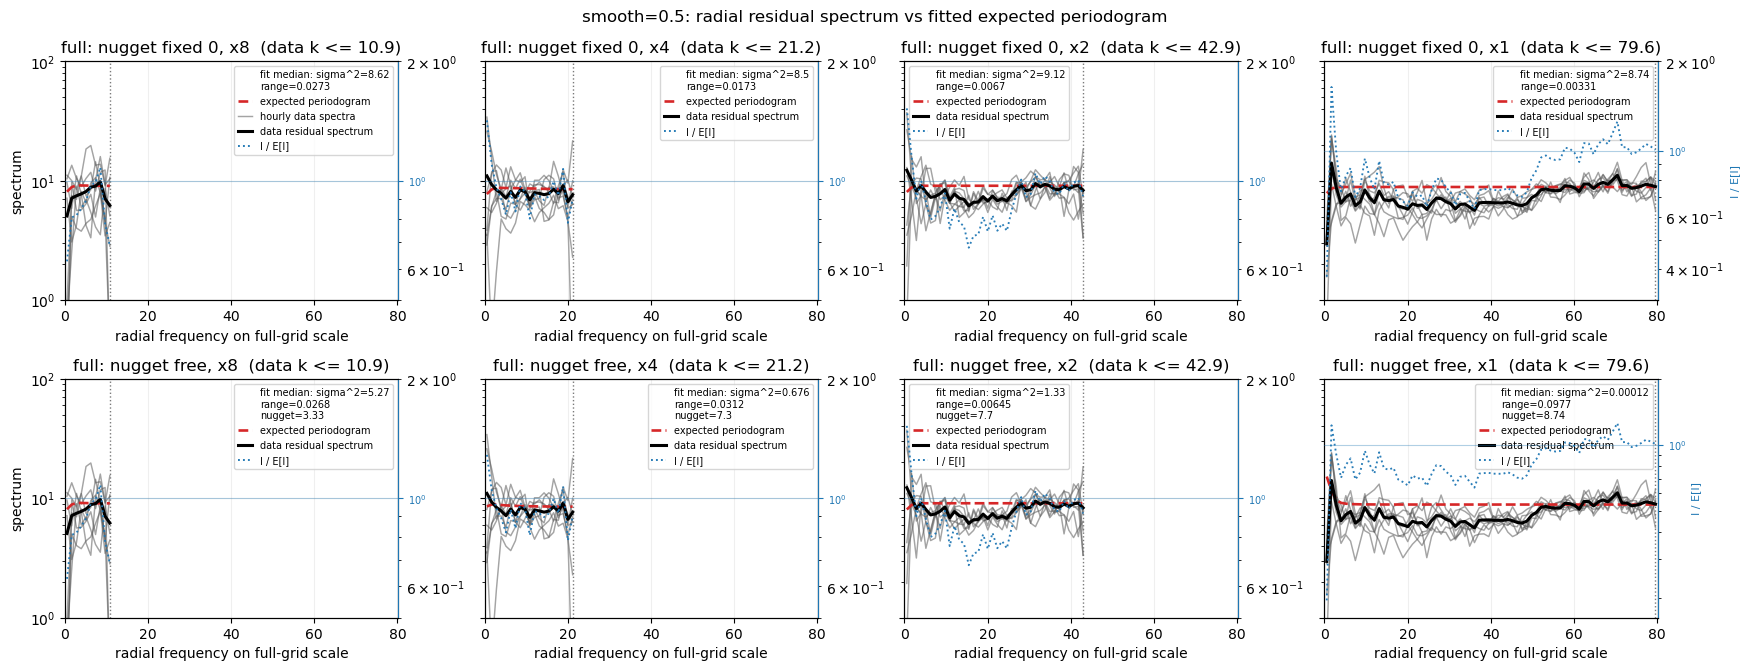

Saved shape diagnostic radial spectrum plot: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_1lat_diff_pure_space_spectral_s05_nugget_compare_hybrid_050826_shape_diagnostic_median_matched_theory_by_variant_resolution.png


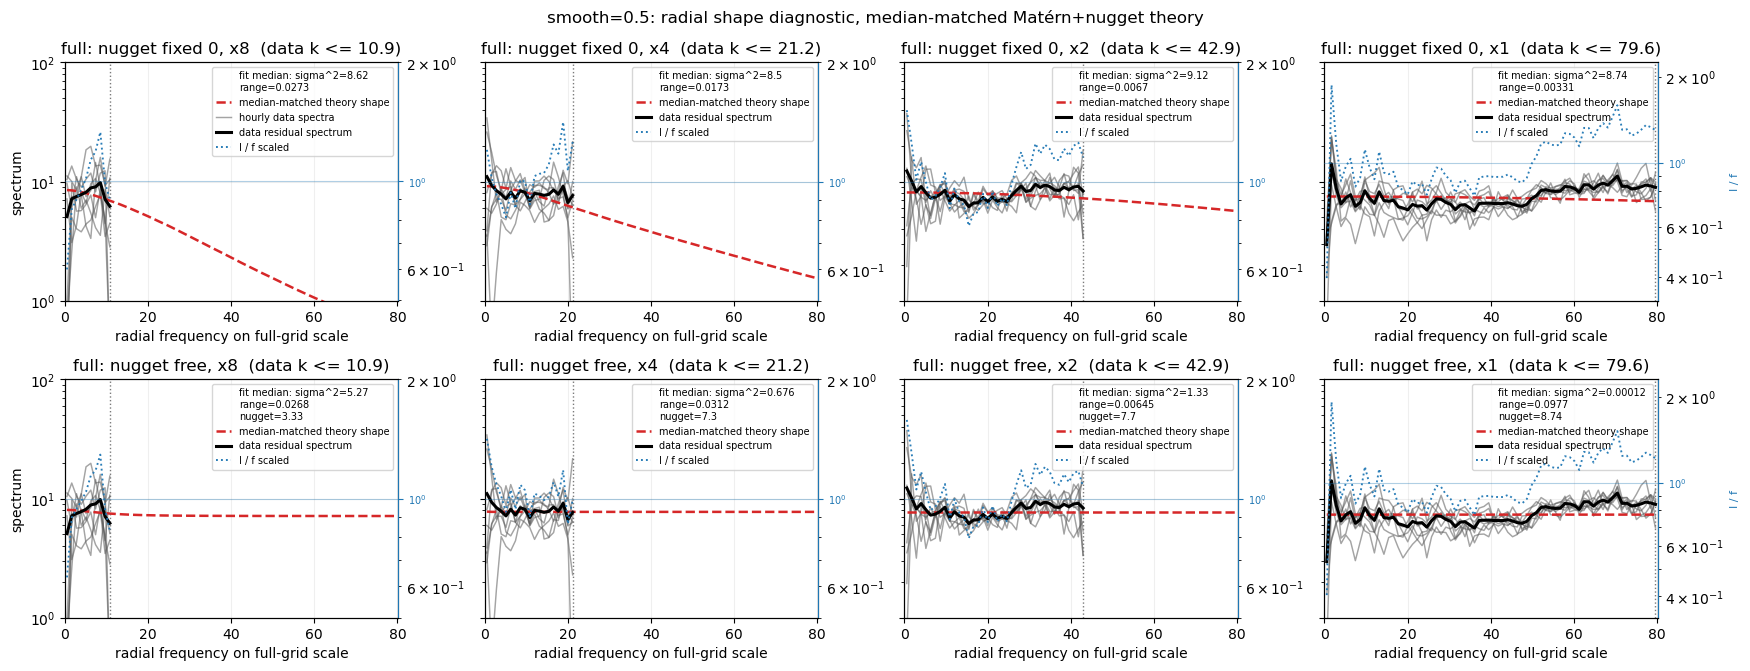

Saved radial expected-vs-rescaled-shape plot: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_1lat_diff_pure_space_spectral_s05_nugget_compare_hybrid_050826_expected_vs_rescaled_matern_shape_by_variant_resolution.png


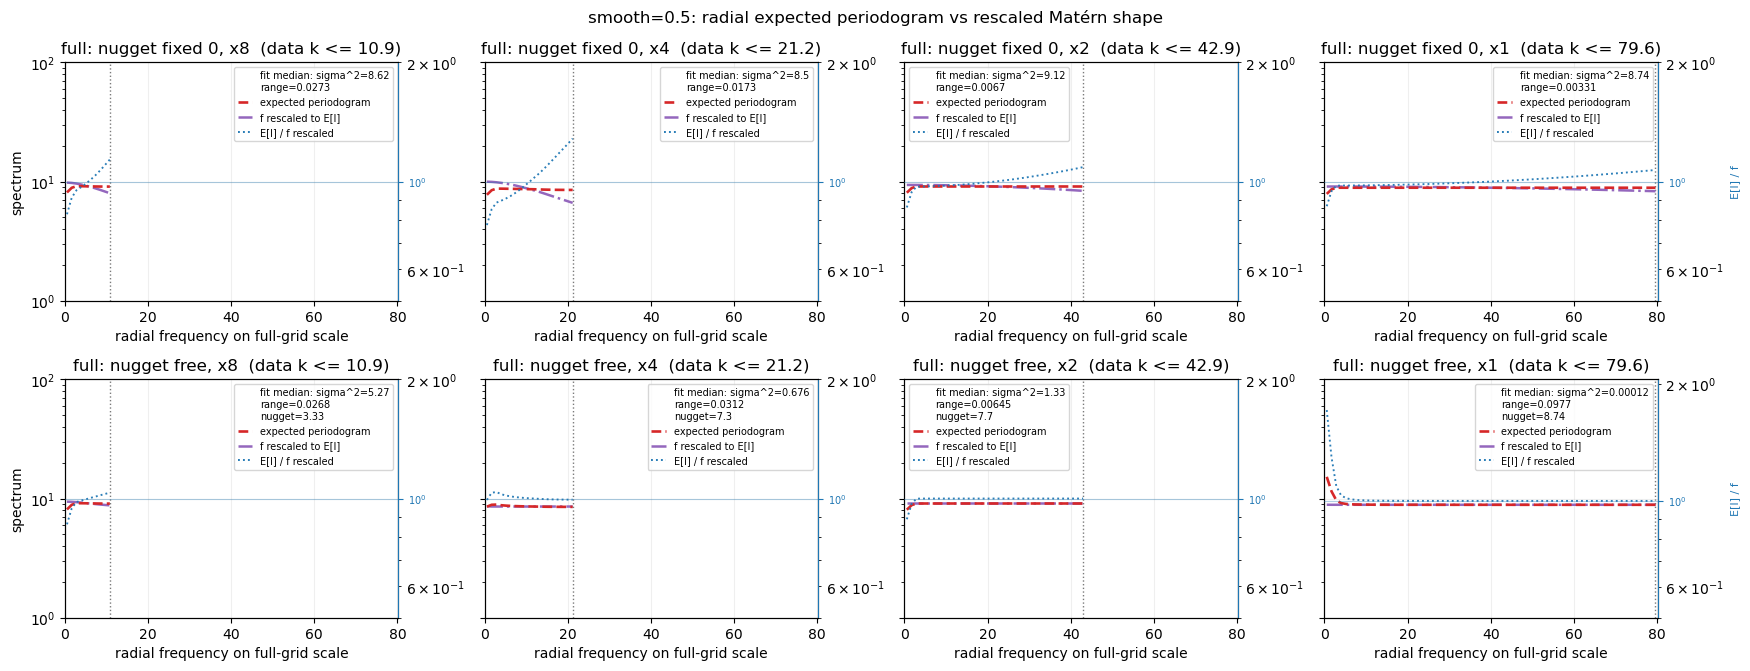

In [12]:

# %%
# Resolution-aware radial spectrum summaries.
# Data spectra are computed on the actual 2D thinned grid for each stride.
# Main theory curves use a DW-style finite-sample expected periodogram:
# fitted covariance + nugget, same mask/taper/FFT normalization, no median scaling.
if 'spectral_df' not in globals():
    spectral_df = pd.read_csv(OUT_DIR / f'{OUT_PREFIX}_radial_spectrum.csv')
required_spectrum_cols = {'theory_spectrum_expected', 'theory_spectrum_scaled'}
missing_spectrum_cols = required_spectrum_cols.difference(spectral_df.columns)
if missing_spectrum_cols:
    raise ValueError(f'spectral_df lacks {sorted(missing_spectrum_cols)}; rerun the RUN_SPECTRUM cell after this update.')

plot_spec = spectral_df.copy()
plot_spec['resolution_label'] = pd.Categorical(
    plot_spec['resolution_label'], categories=[f'x{s}' for s in RESOLUTION_STRIDES], ordered=True
)

avg_low_data = (
    plot_spec.dropna(subset=['data_spectrum'])
    .groupby(['variant', 'resolution_label', 'resolution_stride', 'k_bin'], observed=False)
    .agg(
        k_mid=('k_mid', 'mean'),
        data_spectrum=('data_spectrum', 'mean'),
        n_hours=('hour_idx', 'nunique'),
        data_k_max=('data_k_max', 'mean'),
    )
    .reset_index()
)
low_path = OUT_DIR / f'{OUT_PREFIX}_radial_spectrum_lowfreq_only_avg.csv'
avg_low_data.to_csv(low_path, index=False)
print('Saved low-frequency data spectrum:', low_path)

avg_theory_full = (
    plot_spec
    .groupby(['variant', 'resolution_label', 'k_bin'], observed=False)
    .agg(
        k_mid=('k_mid', 'mean'),
        theory_spectrum_expected=('theory_spectrum_expected', 'mean'),
        theory_spectrum_scaled=('theory_spectrum_scaled', 'mean'),
    )
    .reset_index()
)

positive_spectrum_vals = pd.concat(
    [
        pd.to_numeric(avg_low_data['data_spectrum'], errors='coerce'),
        pd.to_numeric(avg_theory_full['theory_spectrum_expected'], errors='coerce'),
    ],
    ignore_index=True,
).replace([np.inf, -np.inf], np.nan).dropna()
positive_spectrum_vals = positive_spectrum_vals[positive_spectrum_vals > 0]
SPECTRUM_YLIM = (1e-1, 1e4) if positive_spectrum_vals.empty else (
    10 ** np.floor(np.log10(float(positive_spectrum_vals.min()))),
    10 ** np.ceil(np.log10(float(positive_spectrum_vals.max()))),
)
print('Radial spectrum y-limits:', SPECTRUM_YLIM)

labels_order = [f'x{s}' for s in RESOLUTION_STRIDES]

def _format_fit_param_label(source_df, variant, resolution_label, direction=None, profile_type=None, prefix='fit median'):
    required = {'variant', 'resolution_label', 'est_sigmasq', 'est_range', 'est_nugget'}
    if source_df is None or source_df.empty or not required.issubset(source_df.columns):
        return None
    df = source_df[
        (source_df['variant'].astype(str) == str(variant))
        & (source_df['resolution_label'].astype(str) == str(resolution_label))
    ].copy()
    if direction is not None and 'direction' in df.columns:
        df = df[df['direction'].astype(str) == str(direction)]
    if profile_type is not None and 'profile_type' in df.columns:
        df = df[df['profile_type'].astype(str) == str(profile_type)]
    if df.empty:
        return None
    key_cols = [
        c for c in ['date_str', 'hour_idx', 'time_key', 'variant', 'resolution_label', 'direction', 'profile_type']
        if c in df.columns
    ]
    if key_cols:
        df = df.drop_duplicates(key_cols)
    sigmasq = float(pd.to_numeric(df['est_sigmasq'], errors='coerce').median())
    range_ = float(pd.to_numeric(df['est_range'], errors='coerce').median())
    nugget = float(pd.to_numeric(df['est_nugget'], errors='coerce').median())
    if not np.isfinite(sigmasq) or not np.isfinite(range_):
        return None
    label = f'{prefix}: sigma^2={sigmasq:.3g}\nrange={range_:.3g}'
    if str(variant) == 'nugget_free' or (np.isfinite(nugget) and abs(nugget) > EPS):
        label += f'\nnugget={nugget:.3g}'
    return label


def _ratio_from_arrays(x_vals, numerator_vals, denominator_vals):
    ratio_df = pd.DataFrame({
        'k_mid': pd.to_numeric(pd.Series(x_vals), errors='coerce'),
        'numerator': pd.to_numeric(pd.Series(numerator_vals), errors='coerce'),
        'denominator': pd.to_numeric(pd.Series(denominator_vals), errors='coerce'),
    }).replace([np.inf, -np.inf], np.nan)
    good = (
        ratio_df['k_mid'].notna()
        & ratio_df['numerator'].notna()
        & ratio_df['denominator'].notna()
        & (ratio_df['numerator'] > 0)
        & (ratio_df['denominator'] > 0)
    )
    ratio_df = ratio_df.loc[good, ['k_mid']].copy()
    if ratio_df.empty:
        ratio_df['ratio'] = []
        return ratio_df
    ratio_df['ratio'] = (
        pd.to_numeric(pd.Series(numerator_vals), errors='coerce').loc[good].to_numpy(dtype=float)
        / pd.to_numeric(pd.Series(denominator_vals), errors='coerce').loc[good].to_numpy(dtype=float)
    )
    return ratio_df.sort_values('k_mid')


def _ratio_frame(numerator_df, denominator_df, numerator_col, denominator_col, x_col='k_mid'):
    if numerator_df is None or denominator_df is None or numerator_df.empty or denominator_df.empty:
        return pd.DataFrame(columns=[x_col, 'ratio'])
    left = numerator_df[[x_col, numerator_col]].copy()
    right = denominator_df[[x_col, denominator_col]].copy()
    left[x_col] = pd.to_numeric(left[x_col], errors='coerce').round(10)
    right[x_col] = pd.to_numeric(right[x_col], errors='coerce').round(10)
    merged = left.merge(right, on=x_col, how='inner')
    if merged.empty:
        return pd.DataFrame(columns=[x_col, 'ratio'])
    return _ratio_from_arrays(merged[x_col], merged[numerator_col], merged[denominator_col])


def _add_ratio_axis(ax, ratio_df, ylabel=None, color='tab:blue'):
    if ratio_df is None or ratio_df.empty:
        return None
    ratio_df = ratio_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['k_mid', 'ratio'])
    ratio_df = ratio_df[ratio_df['ratio'] > 0].sort_values('k_mid')
    if ratio_df.empty:
        return None
    ratio_ax = ax.twinx()
    ratio_ax.plot(ratio_df['k_mid'], ratio_df['ratio'], color=color, linewidth=1.35, linestyle=':', alpha=0.95, zorder=8)
    ratio_ax.axhline(1.0, color=color, linewidth=0.8, linestyle='-', alpha=0.35, zorder=7)
    ratio_ax.set_yscale('log')
    vals = pd.to_numeric(ratio_df['ratio'], errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
    vals = vals[vals > 0]
    if not vals.empty:
        lo_raw = float(vals.min())
        hi_raw = float(vals.max())
        lo = max(1e-3, min(0.5, lo_raw / 1.2))
        hi = min(1e3, max(2.0, hi_raw * 1.2))
        if np.isfinite(lo) and np.isfinite(hi) and lo < hi:
            ratio_ax.set_ylim(lo, hi)
    ratio_ax.tick_params(axis='y', colors=color, labelsize=7)
    ratio_ax.spines['right'].set_color(color)
    ratio_ax.grid(False)
    if ylabel:
        ratio_ax.set_ylabel(ylabel, color=color, fontsize=8)
    return ratio_ax


def _expected_rescaled_shape_frame(sub_theory):
    curve = sub_theory[['k_mid', 'theory_spectrum_expected', 'theory_spectrum_scaled']].copy()
    curve = curve.replace([np.inf, -np.inf], np.nan).dropna(
        subset=['k_mid', 'theory_spectrum_expected', 'theory_spectrum_scaled']
    )
    curve = curve[(curve['k_mid'] > 0) & (curve['theory_spectrum_expected'] > 0) & (curve['theory_spectrum_scaled'] > 0)]
    if curve.empty:
        curve['theory_spectrum_shape_rescaled_to_expected'] = []
        return curve
    scale_to_expected = scale_theory_to_data(
        curve['theory_spectrum_expected'], curve['theory_spectrum_scaled'], method='median'
    )
    curve['theory_spectrum_shape_rescaled_to_expected'] = curve['theory_spectrum_scaled'] * scale_to_expected
    return curve

row_specs = [('nugget0', 'full: nugget fixed 0'), ('nugget_free', 'full: nugget free')]
fig, axes = plt.subplots(len(row_specs), len(labels_order), figsize=(4.4 * len(labels_order), 3.4 * len(row_specs)), sharey=True)
if len(row_specs) == 1:
    axes = np.asarray([axes])

for i, (variant, row_title) in enumerate(row_specs):
    for j, label in enumerate(labels_order):
        ax = axes[i, j]
        sub_data = avg_low_data[
            (avg_low_data['variant'] == variant)
            & (avg_low_data['resolution_label'].astype(str) == label)
            & (avg_low_data['k_mid'] > 0)
        ]
        sub_theory = avg_theory_full[
            (avg_theory_full['variant'] == variant)
            & (avg_theory_full['resolution_label'].astype(str) == label)
            & (avg_theory_full['k_mid'] > 0)
        ]
        hour_sub = plot_spec[
            (plot_spec['variant'] == variant)
            & (plot_spec['resolution_label'].astype(str) == label)
            & (plot_spec['k_mid'] > 0)
            & plot_spec['data_spectrum'].notna()
        ]
        if sub_data.empty or sub_theory.empty:
            ax.set_visible(False)
            continue
        k_cut = float(sub_data['data_k_max'].dropna().iloc[0]) if sub_data['data_k_max'].notna().any() else float(sub_data['k_mid'].max())
        param_label = _format_fit_param_label(plot_spec, variant, label)
        if param_label:
            ax.plot([], [], color='none', label=param_label)
        ax.plot(sub_theory['k_mid'], sub_theory['theory_spectrum_expected'], color='tab:red', linewidth=1.9, linestyle='--', label='expected periodogram', zorder=3)
        for h_i, (_, hs) in enumerate(hour_sub.groupby('hour_idx')):
            hour_label = 'hourly data spectra' if (i == 0 and j == 0 and h_i == 0) else None
            ax.plot(hs['k_mid'], hs['data_spectrum'], color='0.35', alpha=0.55, linewidth=1.05, label=hour_label, zorder=1)
        ax.plot(sub_data['k_mid'], sub_data['data_spectrum'], color='black', linewidth=2.2, label='data residual spectrum', zorder=4)
        ratio_df = _ratio_frame(sub_data, sub_theory, 'data_spectrum', 'theory_spectrum_expected')
        _add_ratio_axis(ax, ratio_df, ylabel='I / E[I]' if j == len(labels_order) - 1 else None)
        ax.plot([], [], color='tab:blue', linewidth=1.35, linestyle=':', label='I / E[I]')
        ax.axvline(k_cut, color='0.45', linewidth=1.0, linestyle=':', alpha=0.95, zorder=2)
        ax.set_xlim(0, FULL_K_PLOT_MAX)
        ax.set_ylim(*SPECTRUM_YLIM)
        ax.set_title(f'{row_title}, {label}  (data k <= {k_cut:.1f})')
        ax.set_xlabel('radial frequency on full-grid scale')
        if j == 0:
            ax.set_ylabel('spectrum')
        ax.set_yscale('log')
        ax.grid(alpha=0.2)
        ax.legend(fontsize=7, handlelength=1.5)

fig.suptitle(f'smooth={SMOOTH}: radial residual spectrum vs fitted expected periodogram')
fig.tight_layout()
combined_spectrum_plot_path = OUT_DIR / f'{OUT_PREFIX}_data_vs_expected_periodogram_by_variant_resolution.png'
fig.savefig(combined_spectrum_plot_path, dpi=180, bbox_inches='tight')
print('Saved radial spectrum plot:', combined_spectrum_plot_path)
plt.show()


# Shape diagnostic: median-matched Matérn+nugget spectral shape.
# This is useful for comparing curvature only; do not read its vertical scale or nugget floor literally.
fig_shape, axes_shape = plt.subplots(len(row_specs), len(labels_order), figsize=(4.4 * len(labels_order), 3.4 * len(row_specs)), sharey=True)
if len(row_specs) == 1:
    axes_shape = np.asarray([axes_shape])

for i, (variant, row_title) in enumerate(row_specs):
    for j, label in enumerate(labels_order):
        ax = axes_shape[i, j]
        sub_data = avg_low_data[
            (avg_low_data['variant'] == variant)
            & (avg_low_data['resolution_label'].astype(str) == label)
            & (avg_low_data['k_mid'] > 0)
        ]
        sub_theory = avg_theory_full[
            (avg_theory_full['variant'] == variant)
            & (avg_theory_full['resolution_label'].astype(str) == label)
            & (avg_theory_full['k_mid'] > 0)
        ]
        hour_sub = plot_spec[
            (plot_spec['variant'] == variant)
            & (plot_spec['resolution_label'].astype(str) == label)
            & (plot_spec['k_mid'] > 0)
            & plot_spec['data_spectrum'].notna()
        ]
        if sub_data.empty or sub_theory.empty:
            ax.set_visible(False)
            continue
        k_cut = float(sub_data['data_k_max'].dropna().iloc[0]) if sub_data['data_k_max'].notna().any() else float(sub_data['k_mid'].max())
        param_label = _format_fit_param_label(plot_spec, variant, label)
        if param_label:
            ax.plot([], [], color='none', label=param_label)
        ax.plot(sub_theory['k_mid'], sub_theory['theory_spectrum_scaled'], color='tab:red', linewidth=1.8, linestyle='--', label='median-matched theory shape', zorder=3)
        for h_i, (_, hs) in enumerate(hour_sub.groupby('hour_idx')):
            hour_label = 'hourly data spectra' if (i == 0 and j == 0 and h_i == 0) else None
            ax.plot(hs['k_mid'], hs['data_spectrum'], color='0.35', alpha=0.55, linewidth=1.05, label=hour_label, zorder=1)
        ax.plot(sub_data['k_mid'], sub_data['data_spectrum'], color='black', linewidth=2.2, label='data residual spectrum', zorder=4)
        ratio_df = _ratio_frame(sub_data, sub_theory, 'data_spectrum', 'theory_spectrum_scaled')
        _add_ratio_axis(ax, ratio_df, ylabel='I / f' if j == len(labels_order) - 1 else None)
        ax.plot([], [], color='tab:blue', linewidth=1.35, linestyle=':', label='I / f scaled')
        ax.axvline(k_cut, color='0.45', linewidth=1.0, linestyle=':', alpha=0.95, zorder=2)
        ax.set_xlim(0, FULL_K_PLOT_MAX)
        ax.set_ylim(*SPECTRUM_YLIM)
        ax.set_title(f'{row_title}, {label}  (data k <= {k_cut:.1f})')
        ax.set_xlabel('radial frequency on full-grid scale')
        if j == 0:
            ax.set_ylabel('spectrum')
        ax.set_yscale('log')
        ax.grid(alpha=0.2)
        ax.legend(fontsize=7, handlelength=1.5)

fig_shape.suptitle(f'smooth={SMOOTH}: radial shape diagnostic, median-matched Matérn+nugget theory')
fig_shape.tight_layout()
shape_diagnostic_plot_path = OUT_DIR / f'{OUT_PREFIX}_shape_diagnostic_median_matched_theory_by_variant_resolution.png'
fig_shape.savefig(shape_diagnostic_plot_path, dpi=180, bbox_inches='tight')
print('Saved shape diagnostic radial spectrum plot:', shape_diagnostic_plot_path)
plt.show()


# Expected-periodogram vs continuous Matérn shape after rescaling f to E[I].
# This isolates finite-grid, mask/taper, and leakage effects from the model shape.
fig_ei_shape, axes_ei_shape = plt.subplots(len(row_specs), len(labels_order), figsize=(4.4 * len(labels_order), 3.4 * len(row_specs)), sharey=True)
if len(row_specs) == 1:
    axes_ei_shape = np.asarray([axes_ei_shape])

for i, (variant, row_title) in enumerate(row_specs):
    for j, label in enumerate(labels_order):
        ax = axes_ei_shape[i, j]
        sub_data = avg_low_data[
            (avg_low_data['variant'] == variant)
            & (avg_low_data['resolution_label'].astype(str) == label)
            & (avg_low_data['k_mid'] > 0)
        ]
        sub_theory = avg_theory_full[
            (avg_theory_full['variant'] == variant)
            & (avg_theory_full['resolution_label'].astype(str) == label)
            & (avg_theory_full['k_mid'] > 0)
        ]
        curve = _expected_rescaled_shape_frame(sub_theory)
        if curve.empty:
            ax.set_visible(False)
            continue
        k_cut = np.nan
        if not sub_data.empty:
            k_cut = float(sub_data['data_k_max'].dropna().iloc[0]) if sub_data['data_k_max'].notna().any() else float(sub_data['k_mid'].max())
        param_label = _format_fit_param_label(plot_spec, variant, label)
        if param_label:
            ax.plot([], [], color='none', label=param_label)
        ax.plot(curve['k_mid'], curve['theory_spectrum_expected'], color='tab:red', linewidth=1.9, linestyle='--', label='expected periodogram', zorder=4)
        ax.plot(curve['k_mid'], curve['theory_spectrum_shape_rescaled_to_expected'], color='tab:purple', linewidth=1.8, linestyle='-.', label='f rescaled to E[I]', zorder=3)
        ratio_df = _ratio_from_arrays(curve['k_mid'], curve['theory_spectrum_expected'], curve['theory_spectrum_shape_rescaled_to_expected'])
        _add_ratio_axis(ax, ratio_df, ylabel='E[I] / f' if j == len(labels_order) - 1 else None)
        ax.plot([], [], color='tab:blue', linewidth=1.35, linestyle=':', label='E[I] / f rescaled')
        if np.isfinite(k_cut):
            ax.axvline(k_cut, color='0.45', linewidth=1.0, linestyle=':', alpha=0.95, zorder=2)
        ax.set_xlim(0, FULL_K_PLOT_MAX)
        ax.set_ylim(*SPECTRUM_YLIM)
        title_suffix = f'  (data k <= {k_cut:.1f})' if np.isfinite(k_cut) else ''
        ax.set_title(f'{row_title}, {label}{title_suffix}')
        ax.set_xlabel('radial frequency on full-grid scale')
        if j == 0:
            ax.set_ylabel('spectrum')
        ax.set_yscale('log')
        ax.grid(alpha=0.2)
        ax.legend(fontsize=7, handlelength=1.5)

fig_ei_shape.suptitle(f'smooth={SMOOTH}: radial expected periodogram vs rescaled Matérn shape')
fig_ei_shape.tight_layout()
ei_shape_plot_path = OUT_DIR / f'{OUT_PREFIX}_expected_vs_rescaled_matern_shape_by_variant_resolution.png'
fig_ei_shape.savefig(ei_shape_plot_path, dpi=180, bbox_inches='tight')
print('Saved radial expected-vs-rescaled-shape plot:', ei_shape_plot_path)
plt.show()



Directional expected-periodogram y-limits: (0.1, 100.0)
Saved directional expected-periodogram plot: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_1lat_diff_pure_space_spectral_s05_nugget_compare_hybrid_050826_directional_data_vs_expected_periodogram_by_variant_resolution.png


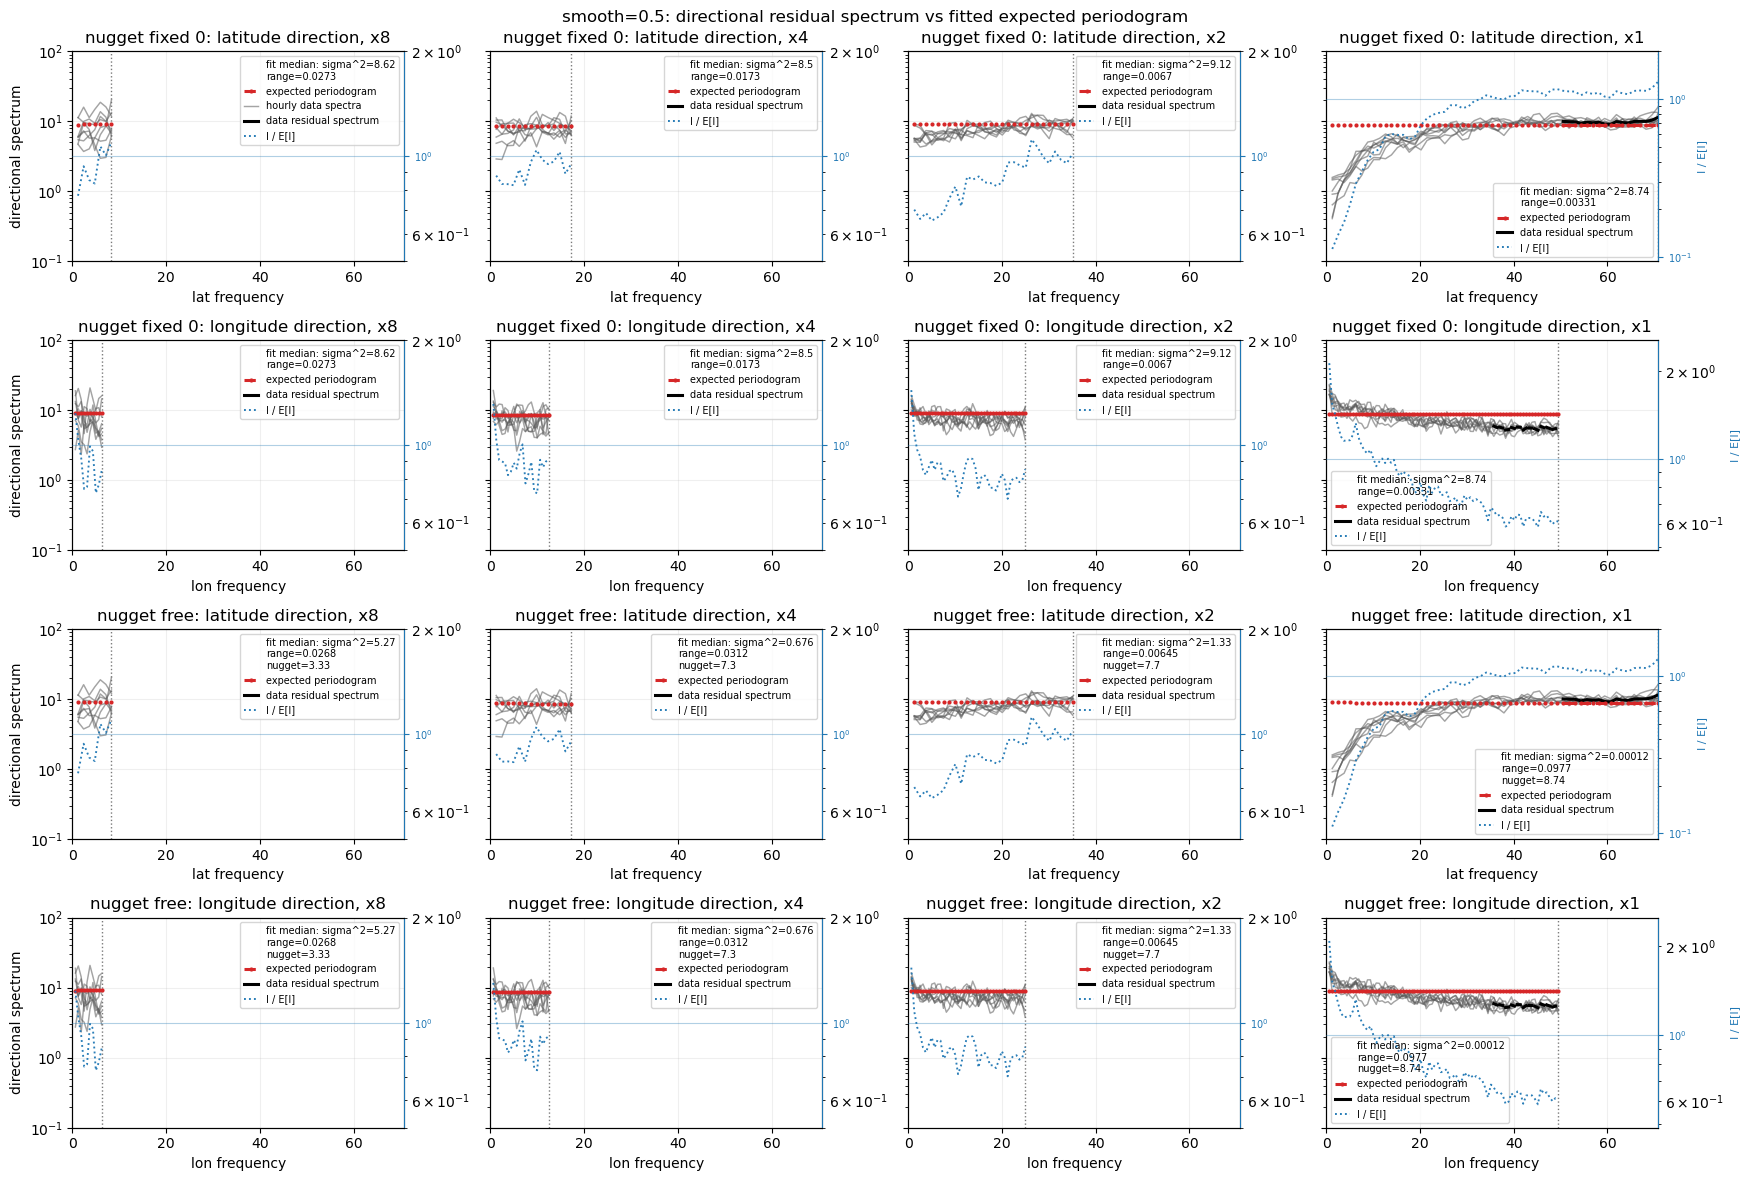

Directional scaled-shape y-limits: (0.1, 100.0)
Saved directional scaled-shape plot: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_1lat_diff_pure_space_spectral_s05_nugget_compare_hybrid_050826_shape_diagnostic_directional_scaled_matern_by_variant_resolution.png


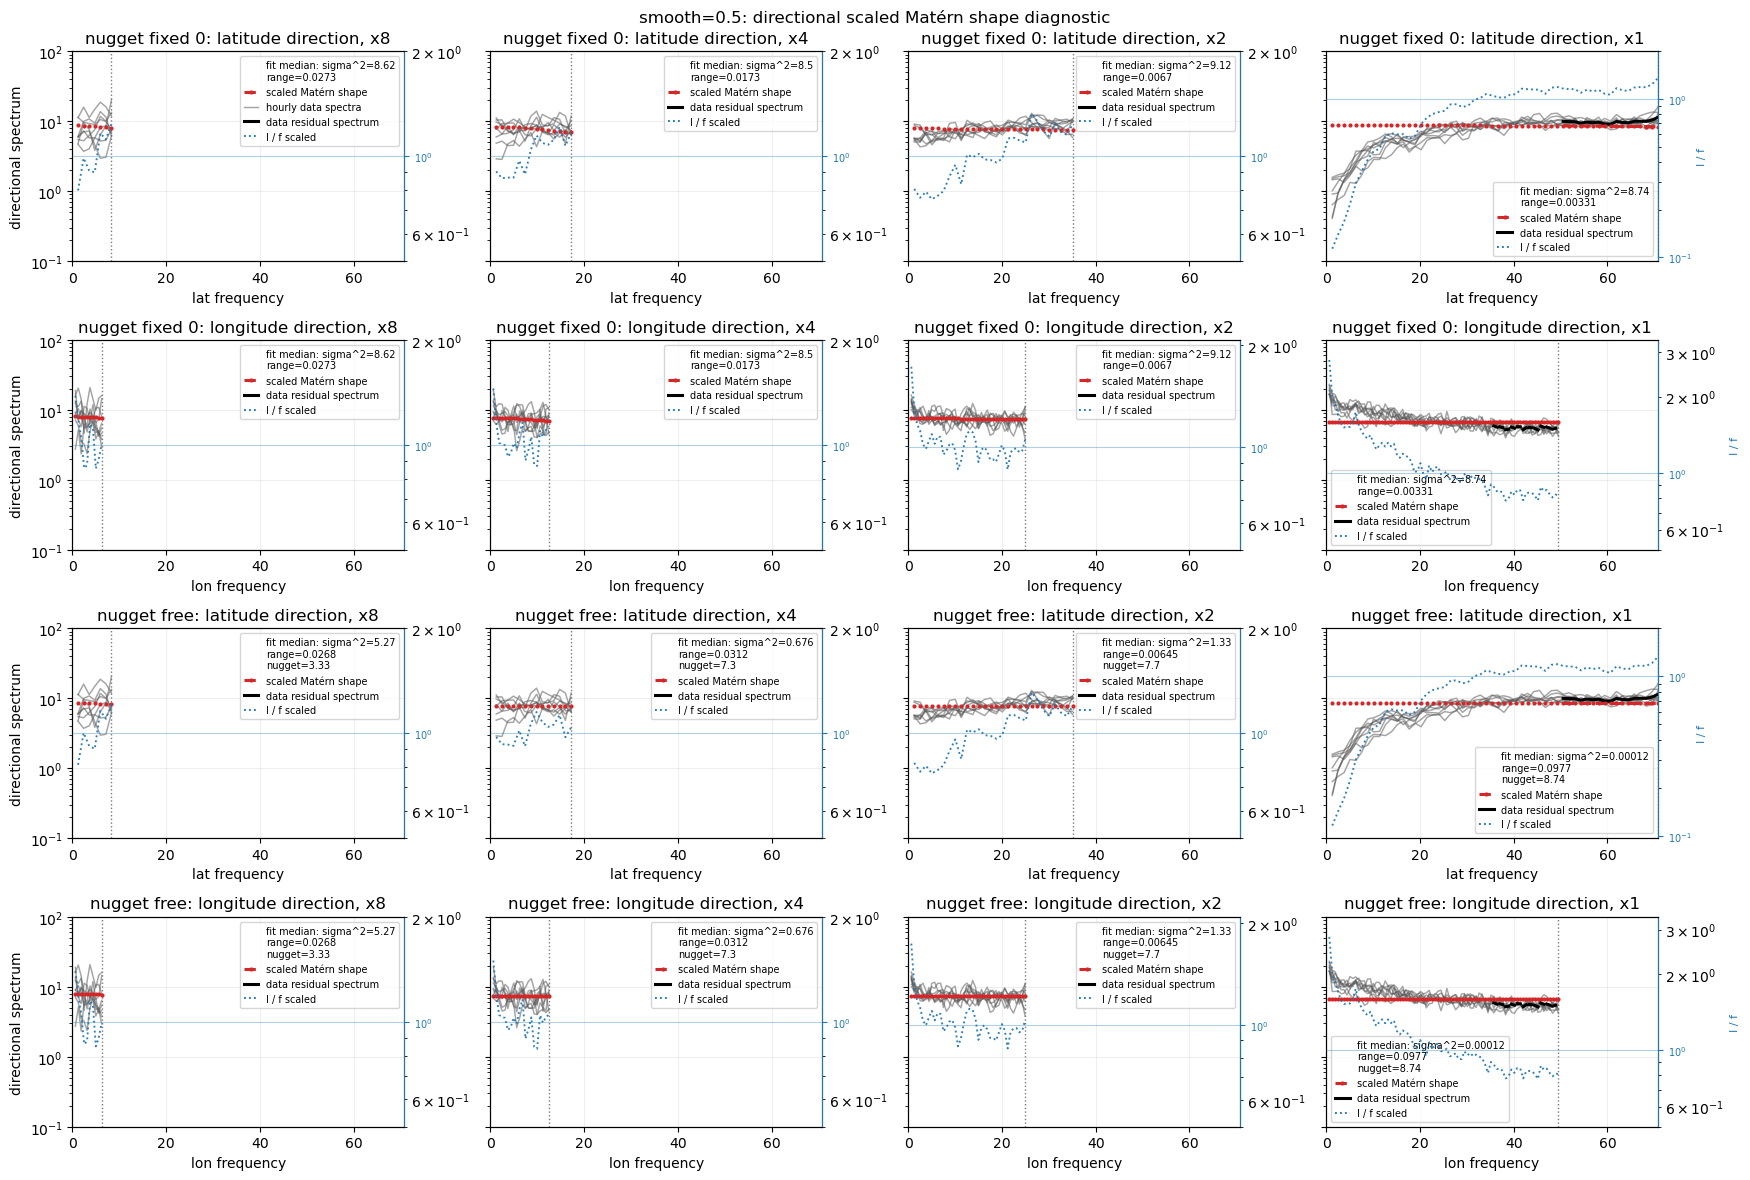

Saved directional expected-vs-rescaled-shape plot: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_1lat_diff_pure_space_spectral_s05_nugget_compare_hybrid_050826_directional_expected_vs_rescaled_matern_shape_by_variant_resolution.png


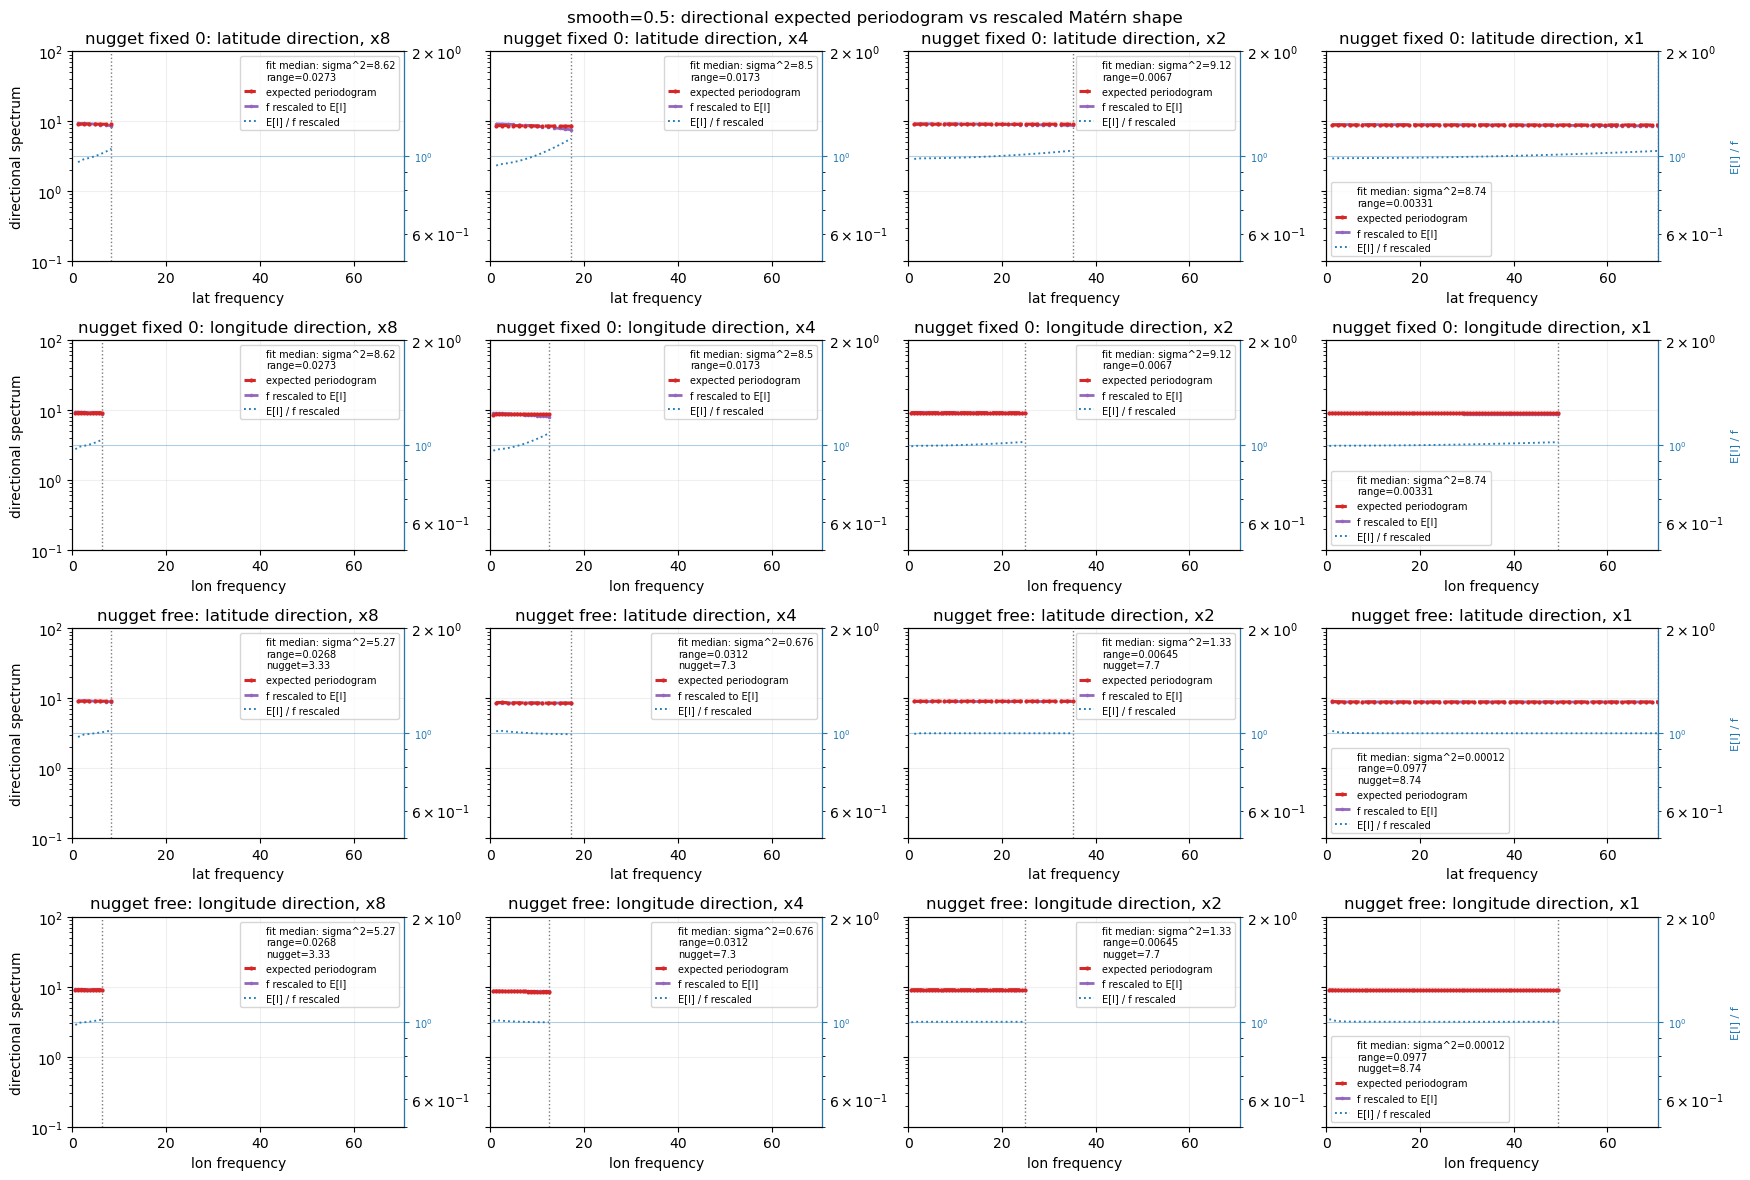

In [13]:

# %%
# Directional lat/lon spectrum diagnostics.
# These are directional summaries of the same 2D masked/tapered/projected FFT
# periodogram used by the radial diagnostic, so empirical and expected curves
# share the same finite-grid convention.
if 'directional_spectral_df' not in globals():
    directional_spectral_df = pd.read_csv(OUT_DIR / f'{OUT_PREFIX}_directional_spectrum_lat_lon.csv')
required_dir_cols = {'theory_spectrum_expected', 'theory_spectrum_scaled'}
missing_dir_cols = required_dir_cols.difference(directional_spectral_df.columns)
if missing_dir_cols:
    raise ValueError(f'directional_spectral_df lacks {sorted(missing_dir_cols)}; rerun the RUN_SPECTRUM cell after this update.')

plot_dir = directional_spectral_df.copy()
plot_dir['resolution_label'] = pd.Categorical(
    plot_dir['resolution_label'], categories=[f'x{s}' for s in RESOLUTION_STRIDES], ordered=True
)

avg_dir_data = (
    plot_dir.dropna(subset=['data_spectrum'])
    .groupby(['variant', 'direction', 'resolution_label', 'resolution_stride', 'k_mid'], observed=False)
    .agg(
        data_spectrum=('data_spectrum', 'mean'),
        n_hours=('hour_idx', 'nunique'),
        data_k_max=('data_k_max', 'mean'),
    )
    .reset_index()
)
avg_dir_theory = (
    plot_dir
    .groupby(['variant', 'direction', 'resolution_label', 'k_mid'], observed=False)
    .agg(
        theory_spectrum_expected=('theory_spectrum_expected', 'mean'),
        theory_spectrum_scaled=('theory_spectrum_scaled', 'mean'),
    )
    .reset_index()
)

dir_expected_vals = pd.concat(
    [
        pd.to_numeric(avg_dir_data['data_spectrum'], errors='coerce'),
        pd.to_numeric(avg_dir_theory['theory_spectrum_expected'], errors='coerce'),
    ],
    ignore_index=True,
).replace([np.inf, -np.inf], np.nan).dropna()
dir_expected_vals = dir_expected_vals[dir_expected_vals > 0]
DIR_EXPECTED_SPECTRUM_YLIM = SPECTRUM_YLIM if dir_expected_vals.empty else (
    10 ** np.floor(np.log10(float(dir_expected_vals.min()))),
    10 ** np.ceil(np.log10(float(dir_expected_vals.max()))),
)
print('Directional expected-periodogram y-limits:', DIR_EXPECTED_SPECTRUM_YLIM)

row_specs = [
    ('nugget0', 'lat', 'nugget fixed 0: latitude direction'),
    ('nugget0', 'lon', 'nugget fixed 0: longitude direction'),
    ('nugget_free', 'lat', 'nugget free: latitude direction'),
    ('nugget_free', 'lon', 'nugget free: longitude direction'),
]
labels_order = [f'x{s}' for s in RESOLUTION_STRIDES]
fig, axes = plt.subplots(len(row_specs), len(labels_order), figsize=(4.4 * len(labels_order), 3.0 * len(row_specs)), sharey=True)

for i, (variant, direction, row_title) in enumerate(row_specs):
    for j, label in enumerate(labels_order):
        ax = axes[i, j]
        sub_data = avg_dir_data[
            (avg_dir_data['variant'] == variant)
            & (avg_dir_data['direction'] == direction)
            & (avg_dir_data['resolution_label'].astype(str) == label)
            & (avg_dir_data['k_mid'] > 0)
        ]
        sub_theory = avg_dir_theory[
            (avg_dir_theory['variant'] == variant)
            & (avg_dir_theory['direction'] == direction)
            & (avg_dir_theory['resolution_label'].astype(str) == label)
            & (avg_dir_theory['k_mid'] > 0)
        ]
        hour_sub = plot_dir[
            (plot_dir['variant'] == variant)
            & (plot_dir['direction'] == direction)
            & (plot_dir['resolution_label'].astype(str) == label)
            & (plot_dir['k_mid'] > 0)
            & plot_dir['data_spectrum'].notna()
        ]
        if sub_data.empty or sub_theory.empty:
            ax.set_visible(False)
            continue
        k_cut = float(sub_data['data_k_max'].dropna().iloc[0]) if sub_data['data_k_max'].notna().any() else float(sub_data['k_mid'].max())
        param_label = _format_fit_param_label(plot_spec, variant, label)
        if param_label:
            ax.plot([], [], color='none', label=param_label)
        ax.plot(sub_theory['k_mid'], sub_theory['theory_spectrum_expected'], color='tab:red', linewidth=2.2, linestyle='--', marker='o', markersize=3.0, markerfacecolor='tab:red', markeredgewidth=0.0, label='expected periodogram', zorder=6)
        for h_i, (_, hs) in enumerate(hour_sub.groupby('hour_idx')):
            hour_label = 'hourly data spectra' if (i == 0 and j == 0 and h_i == 0) else None
            ax.plot(hs['k_mid'], hs['data_spectrum'], color='0.35', alpha=0.55, linewidth=1.05, label=hour_label, zorder=1)
        ax.plot(sub_data['k_mid'], sub_data['data_spectrum'], color='black', linewidth=2.2, label='data residual spectrum', zorder=4)
        ratio_df = _ratio_frame(sub_data, sub_theory, 'data_spectrum', 'theory_spectrum_expected')
        _add_ratio_axis(ax, ratio_df, ylabel='I / E[I]' if j == len(labels_order) - 1 else None)
        ax.plot([], [], color='tab:blue', linewidth=1.35, linestyle=':', label='I / E[I]')
        ax.axvline(k_cut, color='0.45', linewidth=1.0, linestyle=':', alpha=0.95, zorder=2)
        ax.set_xlim(0, max(float(sub_theory['k_mid'].max()), float(sub_data['k_mid'].max())))
        ax.set_ylim(*DIR_EXPECTED_SPECTRUM_YLIM)
        ax.set_title(f'{row_title}, {label}')
        ax.set_xlabel(f'{direction} frequency')
        if j == 0:
            ax.set_ylabel('directional spectrum')
        ax.set_yscale('log')
        ax.grid(alpha=0.2)
        ax.legend(fontsize=7, handlelength=1.5)

fig.suptitle(f'smooth={SMOOTH}: directional residual spectrum vs fitted expected periodogram')
fig.tight_layout()
directional_expected_plot_path = OUT_DIR / f'{OUT_PREFIX}_directional_data_vs_expected_periodogram_by_variant_resolution.png'
fig.savefig(directional_expected_plot_path, dpi=180, bbox_inches='tight')
print('Saved directional expected-periodogram plot:', directional_expected_plot_path)
plt.show()


dir_shape_vals = pd.concat(
    [
        pd.to_numeric(avg_dir_data['data_spectrum'], errors='coerce'),
        pd.to_numeric(avg_dir_theory['theory_spectrum_scaled'], errors='coerce'),
    ],
    ignore_index=True,
).replace([np.inf, -np.inf], np.nan).dropna()
dir_shape_vals = dir_shape_vals[dir_shape_vals > 0]
DIR_SHAPE_SPECTRUM_YLIM = SPECTRUM_YLIM if dir_shape_vals.empty else (
    10 ** np.floor(np.log10(float(dir_shape_vals.min()))),
    10 ** np.ceil(np.log10(float(dir_shape_vals.max()))),
)
print('Directional scaled-shape y-limits:', DIR_SHAPE_SPECTRUM_YLIM)

fig_shape, axes_shape = plt.subplots(len(row_specs), len(labels_order), figsize=(4.4 * len(labels_order), 3.0 * len(row_specs)), sharey=True)
for i, (variant, direction, row_title) in enumerate(row_specs):
    for j, label in enumerate(labels_order):
        ax = axes_shape[i, j]
        sub_data = avg_dir_data[
            (avg_dir_data['variant'] == variant)
            & (avg_dir_data['direction'] == direction)
            & (avg_dir_data['resolution_label'].astype(str) == label)
            & (avg_dir_data['k_mid'] > 0)
        ]
        sub_theory = avg_dir_theory[
            (avg_dir_theory['variant'] == variant)
            & (avg_dir_theory['direction'] == direction)
            & (avg_dir_theory['resolution_label'].astype(str) == label)
            & (avg_dir_theory['k_mid'] > 0)
        ]
        hour_sub = plot_dir[
            (plot_dir['variant'] == variant)
            & (plot_dir['direction'] == direction)
            & (plot_dir['resolution_label'].astype(str) == label)
            & (plot_dir['k_mid'] > 0)
            & plot_dir['data_spectrum'].notna()
        ]
        if sub_data.empty or sub_theory.empty:
            ax.set_visible(False)
            continue
        k_cut = float(sub_data['data_k_max'].dropna().iloc[0]) if sub_data['data_k_max'].notna().any() else float(sub_data['k_mid'].max())
        param_label = _format_fit_param_label(plot_spec, variant, label)
        if param_label:
            ax.plot([], [], color='none', label=param_label)
        ax.plot(sub_theory['k_mid'], sub_theory['theory_spectrum_scaled'], color='tab:red', linewidth=2.2, linestyle='--', marker='o', markersize=3.0, markerfacecolor='tab:red', markeredgewidth=0.0, label='scaled Matérn shape', zorder=6)
        for h_i, (_, hs) in enumerate(hour_sub.groupby('hour_idx')):
            hour_label = 'hourly data spectra' if (i == 0 and j == 0 and h_i == 0) else None
            ax.plot(hs['k_mid'], hs['data_spectrum'], color='0.35', alpha=0.55, linewidth=1.05, label=hour_label, zorder=1)
        ax.plot(sub_data['k_mid'], sub_data['data_spectrum'], color='black', linewidth=2.2, label='data residual spectrum', zorder=4)
        ratio_df = _ratio_frame(sub_data, sub_theory, 'data_spectrum', 'theory_spectrum_scaled')
        _add_ratio_axis(ax, ratio_df, ylabel='I / f' if j == len(labels_order) - 1 else None)
        ax.plot([], [], color='tab:blue', linewidth=1.35, linestyle=':', label='I / f scaled')
        ax.axvline(k_cut, color='0.45', linewidth=1.0, linestyle=':', alpha=0.95, zorder=2)
        ax.set_xlim(0, max(float(sub_theory['k_mid'].max()), float(sub_data['k_mid'].max())))
        ax.set_ylim(*DIR_SHAPE_SPECTRUM_YLIM)
        ax.set_title(f'{row_title}, {label}')
        ax.set_xlabel(f'{direction} frequency')
        if j == 0:
            ax.set_ylabel('directional spectrum')
        ax.set_yscale('log')
        ax.grid(alpha=0.2)
        ax.legend(fontsize=7, handlelength=1.5)

fig_shape.suptitle(f'smooth={SMOOTH}: directional scaled Matérn shape diagnostic')
fig_shape.tight_layout()
directional_shape_plot_path = OUT_DIR / f'{OUT_PREFIX}_shape_diagnostic_directional_scaled_matern_by_variant_resolution.png'
fig_shape.savefig(directional_shape_plot_path, dpi=180, bbox_inches='tight')
print('Saved directional scaled-shape plot:', directional_shape_plot_path)
plt.show()


# Directional expected-periodogram vs continuous Matérn shape after rescaling f to E[I].
fig_ei_dir_shape, axes_ei_dir_shape = plt.subplots(len(row_specs), len(labels_order), figsize=(4.4 * len(labels_order), 3.0 * len(row_specs)), sharey=True)
for i, (variant, direction, row_title) in enumerate(row_specs):
    for j, label in enumerate(labels_order):
        ax = axes_ei_dir_shape[i, j]
        sub_data = avg_dir_data[
            (avg_dir_data['variant'] == variant)
            & (avg_dir_data['direction'] == direction)
            & (avg_dir_data['resolution_label'].astype(str) == label)
            & (avg_dir_data['k_mid'] > 0)
        ]
        sub_theory = avg_dir_theory[
            (avg_dir_theory['variant'] == variant)
            & (avg_dir_theory['direction'] == direction)
            & (avg_dir_theory['resolution_label'].astype(str) == label)
            & (avg_dir_theory['k_mid'] > 0)
        ]
        curve = _expected_rescaled_shape_frame(sub_theory)
        if curve.empty:
            ax.set_visible(False)
            continue
        k_cut = np.nan
        if not sub_data.empty:
            k_cut = float(sub_data['data_k_max'].dropna().iloc[0]) if sub_data['data_k_max'].notna().any() else float(sub_data['k_mid'].max())
        param_label = _format_fit_param_label(plot_spec, variant, label)
        if param_label:
            ax.plot([], [], color='none', label=param_label)
        ax.plot(curve['k_mid'], curve['theory_spectrum_expected'], color='tab:red', linewidth=2.2, linestyle='--', marker='o', markersize=3.0, markerfacecolor='tab:red', markeredgewidth=0.0, label='expected periodogram', zorder=6)
        ax.plot(curve['k_mid'], curve['theory_spectrum_shape_rescaled_to_expected'], color='tab:purple', linewidth=2.0, linestyle='-.', marker='o', markersize=2.6, markerfacecolor='tab:purple', markeredgewidth=0.0, label='f rescaled to E[I]', zorder=5)
        ratio_df = _ratio_from_arrays(curve['k_mid'], curve['theory_spectrum_expected'], curve['theory_spectrum_shape_rescaled_to_expected'])
        _add_ratio_axis(ax, ratio_df, ylabel='E[I] / f' if j == len(labels_order) - 1 else None)
        ax.plot([], [], color='tab:blue', linewidth=1.35, linestyle=':', label='E[I] / f rescaled')
        if np.isfinite(k_cut):
            ax.axvline(k_cut, color='0.45', linewidth=1.0, linestyle=':', alpha=0.95, zorder=2)
        x_max = float(curve['k_mid'].max())
        if not sub_data.empty:
            x_max = max(x_max, float(sub_data['k_mid'].max()))
        ax.set_xlim(0, x_max)
        ax.set_ylim(*DIR_EXPECTED_SPECTRUM_YLIM)
        ax.set_title(f'{row_title}, {label}')
        ax.set_xlabel(f'{direction} frequency')
        if j == 0:
            ax.set_ylabel('directional spectrum')
        ax.set_yscale('log')
        ax.grid(alpha=0.2)
        ax.legend(fontsize=7, handlelength=1.5)

fig_ei_dir_shape.suptitle(f'smooth={SMOOTH}: directional expected periodogram vs rescaled Matérn shape')
fig_ei_dir_shape.tight_layout()
directional_ei_shape_plot_path = OUT_DIR / f'{OUT_PREFIX}_directional_expected_vs_rescaled_matern_shape_by_variant_resolution.png'
fig_ei_dir_shape.savefig(directional_ei_shape_plot_path, dpi=180, bbox_inches='tight')
print('Saved directional expected-vs-rescaled-shape plot:', directional_ei_shape_plot_path)
plt.show()


Saved partial-profile scaled Matérn shape spectrum: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_1lat_diff_pure_space_spectral_s05_nugget_compare_hybrid_050826_partial_profile_radial_spectrum.csv
Saved partial-profile scaled Matérn shape diagnostic plot: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_1lat_diff_pure_space_spectral_s05_nugget_compare_hybrid_050826_partial_profile_shape_diagnostic_scaled_matern.png


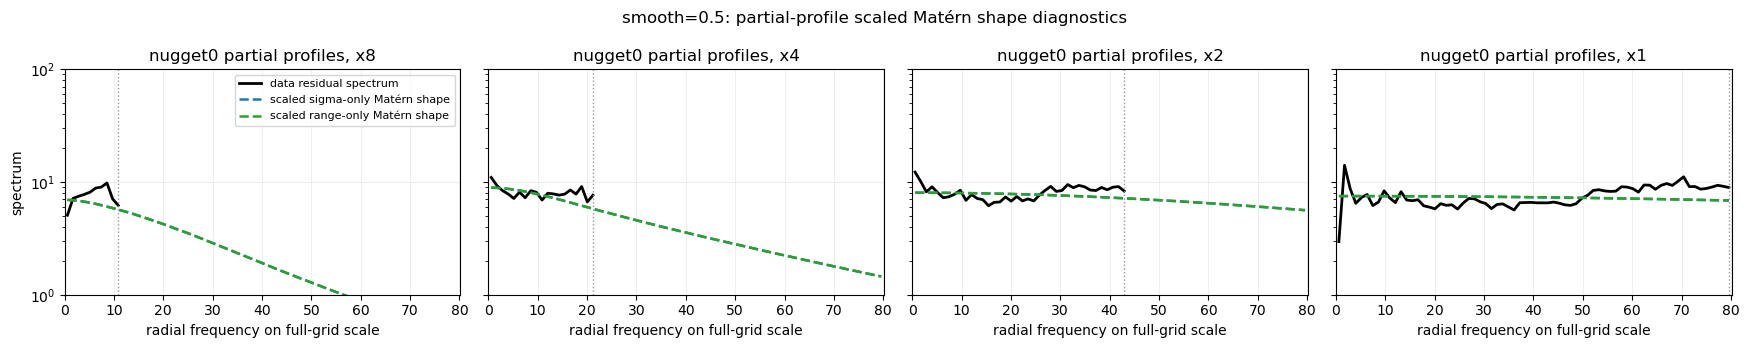

In [14]:

# %%
# Scaled Matérn shape diagnostics for partial-profile fits.
# This keeps the original partial-profile spectral comparison, but writes only
# the median-matched shape curves rather than raw continuous f(omega) output.
if 'profile_df' not in globals() or profile_df.empty:
    profile_path = OUT_DIR / f'{OUT_PREFIX}_partial_profile.csv'
    profile_df = pd.read_csv(profile_path) if profile_path.exists() else pd.DataFrame()

if RUN_SPECTRUM and not profile_df.empty:
    profile_spectral_rows = []
    for r in profile_df.itertuples(index=False):
        grid, mask, time_key, n_valid_spectrum, lat_axis, lon_axis = detrended_residual_grid(
            int(r.hour_idx), int(r.resolution_stride)
        )
        data_p = masked_periodogram(grid, mask)
        k_data, omega2_data, _, _ = frequency_grid_for_axes(lat_axis, lon_axis)
        data_rad = radial_average(data_p, k_data).rename(columns={'spectrum': 'data_spectrum'})

        theory_p = matern_spectrum_shape(r.est_sigmasq, r.est_range, r.est_nugget, SPECTRAL_SMOOTH, OMEGA2_FULL)
        theory_rad = radial_average(theory_p, K_FULL_RADIAL).rename(columns={'spectrum': 'theory_spectrum'})
        merged = theory_rad.merge(data_rad[['k_bin', 'data_spectrum', 'n_freq']], on='k_bin', how='left', suffixes=('', '_data'))
        scale = scale_theory_to_data(merged['data_spectrum'], merged['theory_spectrum'], method='geomean')
        merged['theory_spectrum_scaled'] = merged['theory_spectrum'] * scale
        data_k_max = float(data_rad['k_mid'].max()) if not data_rad.empty else np.nan

        for m in merged.itertuples(index=False):
            profile_spectral_rows.append({
                'date_str': str(r.date_str),
                'hour_idx': int(r.hour_idx),
                'time_key': str(r.time_key),
                'resolution_stride': int(r.resolution_stride),
                'resolution_label': str(r.resolution_label),
                'variant': str(r.variant),
                'profile_type': str(r.profile_type),
                'fit_type': str(r.profile_type),
                'smooth': float(SMOOTH),
                'n_valid_spectrum': int(n_valid_spectrum),
                'est_sigmasq': float(r.est_sigmasq),
                'est_range': float(r.est_range),
                'est_nugget': float(r.est_nugget),
                'k_bin': int(m.k_bin),
                'k_mid': float(m.k_mid),
                'k_mean': float(m.k_mean),
                'n_freq': int(getattr(m, 'n_freq_data')) if pd.notna(getattr(m, 'n_freq_data', np.nan)) else 0,
                'data_k_max': data_k_max,
                'data_spectrum': float(m.data_spectrum) if pd.notna(m.data_spectrum) else np.nan,
                'theory_spectrum_scaled': float(m.theory_spectrum_scaled),
                'theory_scale_to_data': scale,
            })

    profile_spectral_df = pd.DataFrame(profile_spectral_rows)
    profile_spectral_path = OUT_DIR / f'{OUT_PREFIX}_partial_profile_radial_spectrum.csv'
    profile_spectral_df.to_csv(profile_spectral_path, index=False)
    print('Saved partial-profile scaled Matérn shape spectrum:', profile_spectral_path)

    plot_prof = profile_spectral_df.copy()
    plot_prof['resolution_label'] = pd.Categorical(
        plot_prof['resolution_label'], categories=[f'x{s}' for s in RESOLUTION_STRIDES], ordered=True
    )
    avg_prof_data = (
        plot_prof.dropna(subset=['data_spectrum'])
        .groupby(['variant', 'profile_type', 'resolution_label', 'resolution_stride', 'k_bin'], observed=False)
        .agg(k_mid=('k_mid', 'mean'), data_spectrum=('data_spectrum', 'mean'), data_k_max=('data_k_max', 'mean'))
        .reset_index()
    )
    avg_prof_theory = (
        plot_prof
        .groupby(['variant', 'profile_type', 'resolution_label', 'k_bin'], observed=False)
        .agg(
            k_mid=('k_mid', 'mean'),
            theory_spectrum_scaled=('theory_spectrum_scaled', 'mean'),
        )
        .reset_index()
    )

    labels_order = [f'x{s}' for s in RESOLUTION_STRIDES]
    fig, axes = plt.subplots(1, len(labels_order), figsize=(4.4 * len(labels_order), 3.5), sharey=True)
    for j, label in enumerate(labels_order):
        ax = axes[j]
        sub_data = avg_prof_data[
            (avg_prof_data['variant'] == 'nugget0')
            & (avg_prof_data['profile_type'] == 'sigma_only')
            & (avg_prof_data['resolution_label'].astype(str) == label)
            & (avg_prof_data['k_mid'] > 0)
        ]
        sub_sigma = avg_prof_theory[
            (avg_prof_theory['variant'] == 'nugget0')
            & (avg_prof_theory['profile_type'] == 'sigma_only')
            & (avg_prof_theory['resolution_label'].astype(str) == label)
            & (avg_prof_theory['k_mid'] > 0)
        ]
        sub_range = avg_prof_theory[
            (avg_prof_theory['variant'] == 'nugget0')
            & (avg_prof_theory['profile_type'] == 'range_only')
            & (avg_prof_theory['resolution_label'].astype(str) == label)
            & (avg_prof_theory['k_mid'] > 0)
        ]
        if sub_data.empty or sub_sigma.empty or sub_range.empty:
            ax.set_visible(False)
            continue
        k_cut = float(sub_data['data_k_max'].dropna().iloc[0]) if sub_data['data_k_max'].notna().any() else float(sub_data['k_mid'].max())
        ax.plot(sub_data['k_mid'], sub_data['data_spectrum'], color='black', linewidth=2.0, label='data residual spectrum')
        ax.plot(sub_sigma['k_mid'], sub_sigma['theory_spectrum_scaled'], color='tab:blue', linewidth=1.8, linestyle='--', label='scaled sigma-only Matérn shape')
        ax.plot(sub_range['k_mid'], sub_range['theory_spectrum_scaled'], color='tab:green', linewidth=1.8, linestyle='--', label='scaled range-only Matérn shape')
        ax.axvline(k_cut, color='0.55', linewidth=1.0, linestyle=':', alpha=0.9)
        ax.set_xlim(0, FULL_K_PLOT_MAX)
        ax.set_ylim(*SPECTRUM_YLIM)
        ax.set_yscale('log')
        ax.grid(alpha=0.2)
        ax.set_title(f'nugget0 partial profiles, {label}')
        ax.set_xlabel('radial frequency on full-grid scale')
        if j == 0:
            ax.set_ylabel('spectrum')
            ax.legend(fontsize=8)

    fig.suptitle(f'smooth={SMOOTH}: partial-profile scaled Matérn shape diagnostics')
    fig.tight_layout()
    partial_profile_plot_path = OUT_DIR / f'{OUT_PREFIX}_partial_profile_shape_diagnostic_scaled_matern.png'
    fig.savefig(partial_profile_plot_path, dpi=180, bbox_inches='tight')
    print('Saved partial-profile scaled Matérn shape diagnostic plot:', partial_profile_plot_path)
    plt.show()

else:
    print('No partial-profile spectra: profile_df is empty or RUN_SPECTRUM is False.')
